# [Step 1] 대리 모델(Surrogate)을 통한 데이터 증강 — v2 (Improved)

> **목표:** ~900개의 생존 시뮬레이션 데이터에서 300초 시계열의 **'절댓값 Max Peak(부호 유지)'**를 추출하고,  
> XGBoost 대리 모델을 학습하여 **10만 개의 가상 P1~P6 조합**에 대한 응력/변형 결과를 예측합니다.

---

### v2 개선 사항
| 항목 | v1 (기존) | v2 (개선) |
|------|-----------|----------|
| 마스터 매칭 | Row_ID 컬럼 의존 | 행 인덱스 기반 자동 매칭 (실제 DOE 구조 반영) |
| 모델 학습 | MultiOutputRegressor 래핑 | **타겟별 개별 XGBoost** (하이퍼파라미터 독립 튜닝 가능) |
| 검증 | 단순 Train/Test Split | **5-Fold CV** + 홀드아웃 테스트 병행 |
| EDA | 없음 | 피크 분포, 상관관계 히트맵, Pred vs Actual 산점도 |
| 이상치 검증 | 없음 | 예측된 가상 데이터의 물리적 범위 이탈 경고 |
| 난수 생성 | 균일분포 | **Latin Hypercube Sampling (LHS)** 옵션 추가 |
| 주석 | 최소 | 모든 셀 상세 주석 |

---

### 핵심 물리 로직: '절댓값 Max Peak' 추출
열 사이클링에서 응력은 가열 시 (+), 냉각 시 (-) 방향으로 진동합니다.  
**단순 max()를 쓰면 냉각 시 압축 응력(음수)의 위험성을 놓칩니다.**  
따라서 `abs().idxmax()`로 절댓값이 가장 큰 시점을 찾되, 그 시점의 **원래 부호를 보존**합니다.

```python
# 절댓값이 가장 큰 시점의 인덱스 -> 해당 시점의 원본 값(부호 유지)
max_abs_idx = df_time[col].abs().idxmax()
peak_value  = df_time.loc[max_abs_idx, col]   # 예: -30 (압축 피크)
```

---
## 0. 환경 설정 및 라이브러리 로드

In [71]:
import os
import re
import glob
import time
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')  # XGBoost deprecation 경고 억제
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# -- 디바이스 설정 (GPU 가용 시 자동 사용) --
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ====================================================================
# [사용자 설정] 아래 경로만 본인 환경에 맞게 수정하세요
# ====================================================================
CSV_FOLDER = r'C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS/data'   # 시계열 CSV들이 저장된 폴더
MASTER_CSV = r'Master_DOE_1200.csv'                  # P1~P6 설계변수 마스터 파일
BASE_DIR = r'C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS'

# 추출 대상 Y 변수 15개 (Time, TempBase 제외)
# 각 변수의 물리적 의미를 주석으로 명시
Y_COLUMNS = [
    'WarpMax',          # 패키지 전체 최대 열변형량 (최소화 메인 타겟 #1)
    'T_Tip_Peel',       # Top 계면 끝단 수직응력 - 박리(Delamination) 원인 (최소화 메인 타겟 #2)
    'T_Tip_Shear',      # Top 계면 끝단 전단응력 - 계면 피로(Fatigue) 유발
    'T_Tip_SEQV',       # Top 끝단 Von Mises 등가응력 - 소성 변형 유발
    'T_Tip_Strain',     # Top 끝단 변형률
    'T_Avg_Peel',       # Top 접합면 평균 수직응력 - 중앙부 Void 유발
    'T_Avg_Shear',      # Top 접합면 평균 전단응력
    'B_Tip_Peel',       # Bottom 끝단 수직응력
    'B_Tip_Shear',      # Bottom 끝단 전단응력
    'B_Tip_SEQV',       # Bottom 끝단 Von Mises 등가응력
    'B_Tip_Strain',     # Bottom 끝단 변형률
    'B_Avg_Peel',       # Bottom 평균 수직응력
    'B_Avg_Shear',      # Bottom 평균 전단응력
    'Die_SX',           # 다이(실리콘 칩) 휨 응력 - Die Crack 유발
    'Die_SY_Max'        # 다이 최대 Y방향 응력 - 모서리 응력 집중
]

# 난수 시드 (재현성 보장)
SEED = 42
np.random.seed(SEED)

print('=== 환경 설정 완료 ===')
print(f'시계열 CSV 폴더 : {CSV_FOLDER}')
print(f'마스터 DOE 파일 : {MASTER_CSV}')
print(f'추출 대상 Y 변수: {len(Y_COLUMNS)}개')

=== 환경 설정 완료 ===
시계열 CSV 폴더 : C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS/data
마스터 DOE 파일 : Master_DOE_1200.csv
추출 대상 Y 변수: 15개


---
## 1. 마스터 DOE 로드 및 생존 CSV 탐지

**데이터 구조 (확인 완료):**
- `Master_DOE_1200.csv`: P1~P6 컬럼만 존재 (Row_ID 없음, 1200행)
  - 행 인덱스(0-based) + 1 = Row_ID로 매핑
  - P1: [0.80, 1.10] / P2: [0.05, 0.09] / P3: [0.60, 0.72]
  - P4: [0.10, 0.30] / P5: [1.20, 1.80] / P6: [0.04, 0.08]
- 시계열 파일: `ML_DATA_Extract_Row_{Row_ID}.csv` (617행 x 17열, 0.1~300초)

In [35]:
# == 1-1. 마스터 DOE 로드 ==
# P1~P6만 존재하는 1200행 파일. Row_ID 컬럼이 없으므로 직접 부여함.
df_master = pd.read_csv(MASTER_CSV)

# Row_ID 생성: 행 인덱스 + 1 = CSV 파일명의 Row 번호와 1:1 대응
# 즉, Master CSV의 1번째 행(index=0) -> Row_ID=1 -> ML_DATA_Extract_Row_1.csv
df_master.insert(0, 'Row_ID', range(1, len(df_master) + 1))

print(f'마스터 DOE 로드 완료: {len(df_master)}개 DP (Design Points)')
print(f'컬럼: {list(df_master.columns)}')
print()

# 각 P 변수의 범위 확인 (몬테카를로 생성 시 바운더리로 사용됨)
print('-- P1~P6 실제 범위 --')
for col in ['P1','P2','P3','P4','P5','P6']:
    print(f'  {col}: [{df_master[col].min():.4f}, {df_master[col].max():.4f}]')

display(df_master.head())

마스터 DOE 로드 완료: 1200개 DP (Design Points)
컬럼: ['Row_ID', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6']

-- P1~P6 실제 범위 --
  P1: [0.8005, 1.0998]
  P2: [0.0500, 0.0899]
  P3: [0.6001, 0.7198]
  P4: [0.1000, 0.2994]
  P5: [1.2003, 1.7997]
  P6: [0.0401, 0.0800]


,Row_ID,P1,P2,P3,P4,P5,P6
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696
2,3,0.8013,0.0512,0.6363,0.2312,1.3751,0.0560
3,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777
4,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779


In [36]:
# == 1-2. 생존 CSV 파일 자동 탐지 ==
# 폴더를 스캔하여 실제 존재하는 시계열 파일의 Row_ID를 파싱
# (시뮬레이션이 터진 DP는 CSV 파일 자체가 생성되지 않음)

# glob으로 해당 폴더의 모든 ML_DATA_Extract_Row_*.csv 파일 탐색
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

# 파일명에서 Row_ID 숫자를 정규식으로 추출
survived_ids = []
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.append(int(match.group(1)))

survived_ids = sorted(survived_ids)

# 생존 통계 출력
n_total = len(df_master)
n_alive = len(survived_ids)
n_dead  = n_total - n_alive

print(f'전체 DP      : {n_total}개')
print(f'생존 CSV     : {n_alive}개 ({n_alive/n_total*100:.1f}%)')
print(f'결측(터진) DP: {n_dead}개 ({n_dead/n_total*100:.1f}%)')
print(f'생존 Row_ID 범위: {min(survived_ids)} ~ {max(survived_ids)}')

전체 DP      : 1200개
생존 CSV     : 766개 (63.8%)
결측(터진) DP: 434개 (36.2%)
생존 Row_ID 범위: 1 ~ 1041


---
## 2. 시계열 데이터에서 '절댓값 Max Peak' 추출 (Feature Extraction)

각 생존 CSV(300초, 617 timestep)에서 15개 Y 채널별로:
1. `abs().idxmax()` -> 절댓값이 최대인 시간 인덱스 탐색
2. 해당 시점의 원본 값(부호 유지)을 피크로 기록

결과: **[Row_ID, P1~P6, Y1_peak ~ Y15_peak]** 형태의 정적 데이터셋 구축

In [37]:
# == 2-1. 생존 데이터 순회 및 Max Peak 추출 ==

valid_data = []     # 정상 추출된 데이터를 누적할 리스트
error_rows = []     # 읽기 오류가 발생한 Row_ID를 기록할 리스트

t_start = time.time()
print(f'{len(survived_ids)}개 생존 CSV에서 Max Peak 추출 시작...')

for i, row_id in enumerate(survived_ids):
    # 시계열 CSV 파일 경로 구성
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 시계열 데이터 로드 (617행 x 17열: Time, TempBase, 15 Y변수)
        df_ts = pd.read_csv(fpath)
        
        # 컬럼명 앞뒤 공백 제거 (CSV 헤더에 공백 포함될 수 있음)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 마스터 DOE에서 해당 Row의 P1~P6 가져오기
        # Row_ID는 1-based이므로, df_master에서 Row_ID == row_id인 행을 찾음
        master_row = df_master[df_master['Row_ID'] == row_id]
        if master_row.empty:
            error_rows.append((row_id, 'Master DOE에 해당 Row_ID 없음'))
            continue
        
        # 결과 딕셔너리 초기화
        peak_dict = {'Row_ID': row_id}
        
        # P1~P6 설계변수 값 저장
        for p_col in ['P1','P2','P3','P4','P5','P6']:
            peak_dict[p_col] = master_row[p_col].values[0]
        
        # === 핵심 로직: 각 Y 채널별 '절댓값 최대 피크(부호 유지)' 추출 ===
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                # Step A: 300초 시계열에서 절댓값이 가장 큰 시간 인덱스 탐색
                #   abs()로 절댓값을 취한 뒤 idxmax()로 최대 위치를 찾음
                max_abs_idx = df_ts[y_col].abs().idxmax()
                
                # Step B: 해당 시점의 원래 값(부호 보존)을 피크로 기록
                #   예) 시계열이 [+10, -30, +20]이면:
                #       abs = [10, 30, 20] -> idxmax = 1 -> 원본값 = -30
                #   이렇게 해야 냉각 시 압축 응력의 위험성을 놓치지 않음
                peak_dict[y_col] = df_ts.loc[max_abs_idx, y_col]
            else:
                # 해당 Y 컬럼이 CSV에 없는 경우 NaN 처리
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))
    
    # 진행률 표시 (200개마다)
    if (i + 1) % 200 == 0:
        print(f'  ... {i+1}/{len(survived_ids)} 처리 완료')

elapsed = time.time() - t_start

# 결과 취합
df_peaks = pd.DataFrame(valid_data)

print(f'\n=== Max Peak 추출 완료 ===')
print(f'성공: {len(df_peaks)}개 / 실패: {len(error_rows)}개 / 소요시간: {elapsed:.1f}초')

if error_rows:
    print(f'\n[경고] 오류 발생 Row (처음 5개): {error_rows[:5]}')

# NaN이 있는 행 확인 및 제거
nan_count = df_peaks[Y_COLUMNS].isnull().any(axis=1).sum()
if nan_count > 0:
    print(f'[경고] {nan_count}개 행에 NaN 존재 -> 해당 행 제거')
    df_peaks = df_peaks.dropna(subset=Y_COLUMNS).reset_index(drop=True)

print(f'\n최종 학습용 데이터: {len(df_peaks)}개')
display(df_peaks.head())

766개 생존 CSV에서 Max Peak 추출 시작...
  ... 200/766 처리 완료
  ... 400/766 처리 완료
  ... 600/766 처리 완료

=== Max Peak 추출 완료 ===
성공: 766개 / 실패: 0개 / 소요시간: 2.2초

최종 학습용 데이터: 766개


,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585,-0.107084,-34.039048,-8.025589,...,0.023255,-3.071933,-5.445917,-2.957903,28.329506,0.002043,0.032548,-2.861042,66.203874,-85.012494
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696,-0.144790,-31.629051,8.315480,...,0.031333,-2.707141,-4.092614,-2.676881,25.607135,0.001761,0.025406,-2.568996,63.021576,-87.551451
2,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777,-0.158005,-38.879585,8.994357,...,0.084601,-2.668019,-4.944124,-2.822713,29.147154,0.001970,-0.027274,-2.938019,61.316208,-86.130069
3,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779,-0.138039,-33.084874,8.631955,...,0.031446,-2.621313,-4.015564,-2.296843,26.291782,0.001684,-0.015385,-2.606656,58.891827,-81.062810
4,7,0.9347,0.0506,0.6789,0.1163,1.6356,0.0661,-0.120482,-41.494301,8.232958,...,0.081118,-2.695119,-5.653280,-2.729163,32.351288,0.002114,0.010124,-2.795657,58.882464,-89.189848


---
## 3. 탐색적 데이터 분석 (EDA)

학습 전 데이터의 분포와 상관관계를 시각화하여 이상 패턴을 사전 진단합니다.

In [38]:
# == 3-1. Y 변수 기술 통계 ==
print('=== Y 변수 기술 통계 (Max Peak 기준) ===')
display(df_peaks[Y_COLUMNS].describe().round(4))

=== Y 변수 기술 통계 (Max Peak 기준) ===


,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
count,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000,766.0000
mean,-0.1358,-35.3963,7.7072,38.0462,0.0035,0.0315,-2.8768,-5.9093,-2.7556,28.3851,0.0020,-0.0028,-2.8754,62.4238,-88.0190
std,0.0183,2.8613,4.2183,3.4331,0.0003,0.0306,0.3268,2.1475,0.4823,1.9841,0.0002,0.0199,0.2964,4.0265,5.6391
min,-0.1728,-47.2917,-13.0566,30.9377,0.0028,-0.0382,-5.2160,-12.5674,-6.0878,23.2101,0.0015,-0.0682,-5.2635,57.6809,-104.0513
25%,-0.1506,-37.2205,8.1772,35.6569,0.0033,0.0102,-2.9845,-7.1059,-3.0310,26.9223,0.0018,-0.0157,-2.9807,59.6692,-92.4053
50%,-0.1351,-35.2977,8.6335,37.7152,0.0035,0.0264,-2.7990,-5.8113,-2.7165,28.2760,0.0020,-0.0048,-2.8146,61.0680,-87.6071
75%,-0.1206,-33.3318,9.0603,39.8609,0.0037,0.0567,-2.6860,-4.8064,-2.4307,29.6056,0.0021,0.0133,-2.6818,64.2367,-83.9122
max,-0.1015,-28.7603,10.6679,56.8349,0.0049,0.1454,-2.3780,11.6636,-1.6600,38.1656,0.0031,0.0407,-2.3874,87.9883,-72.2885


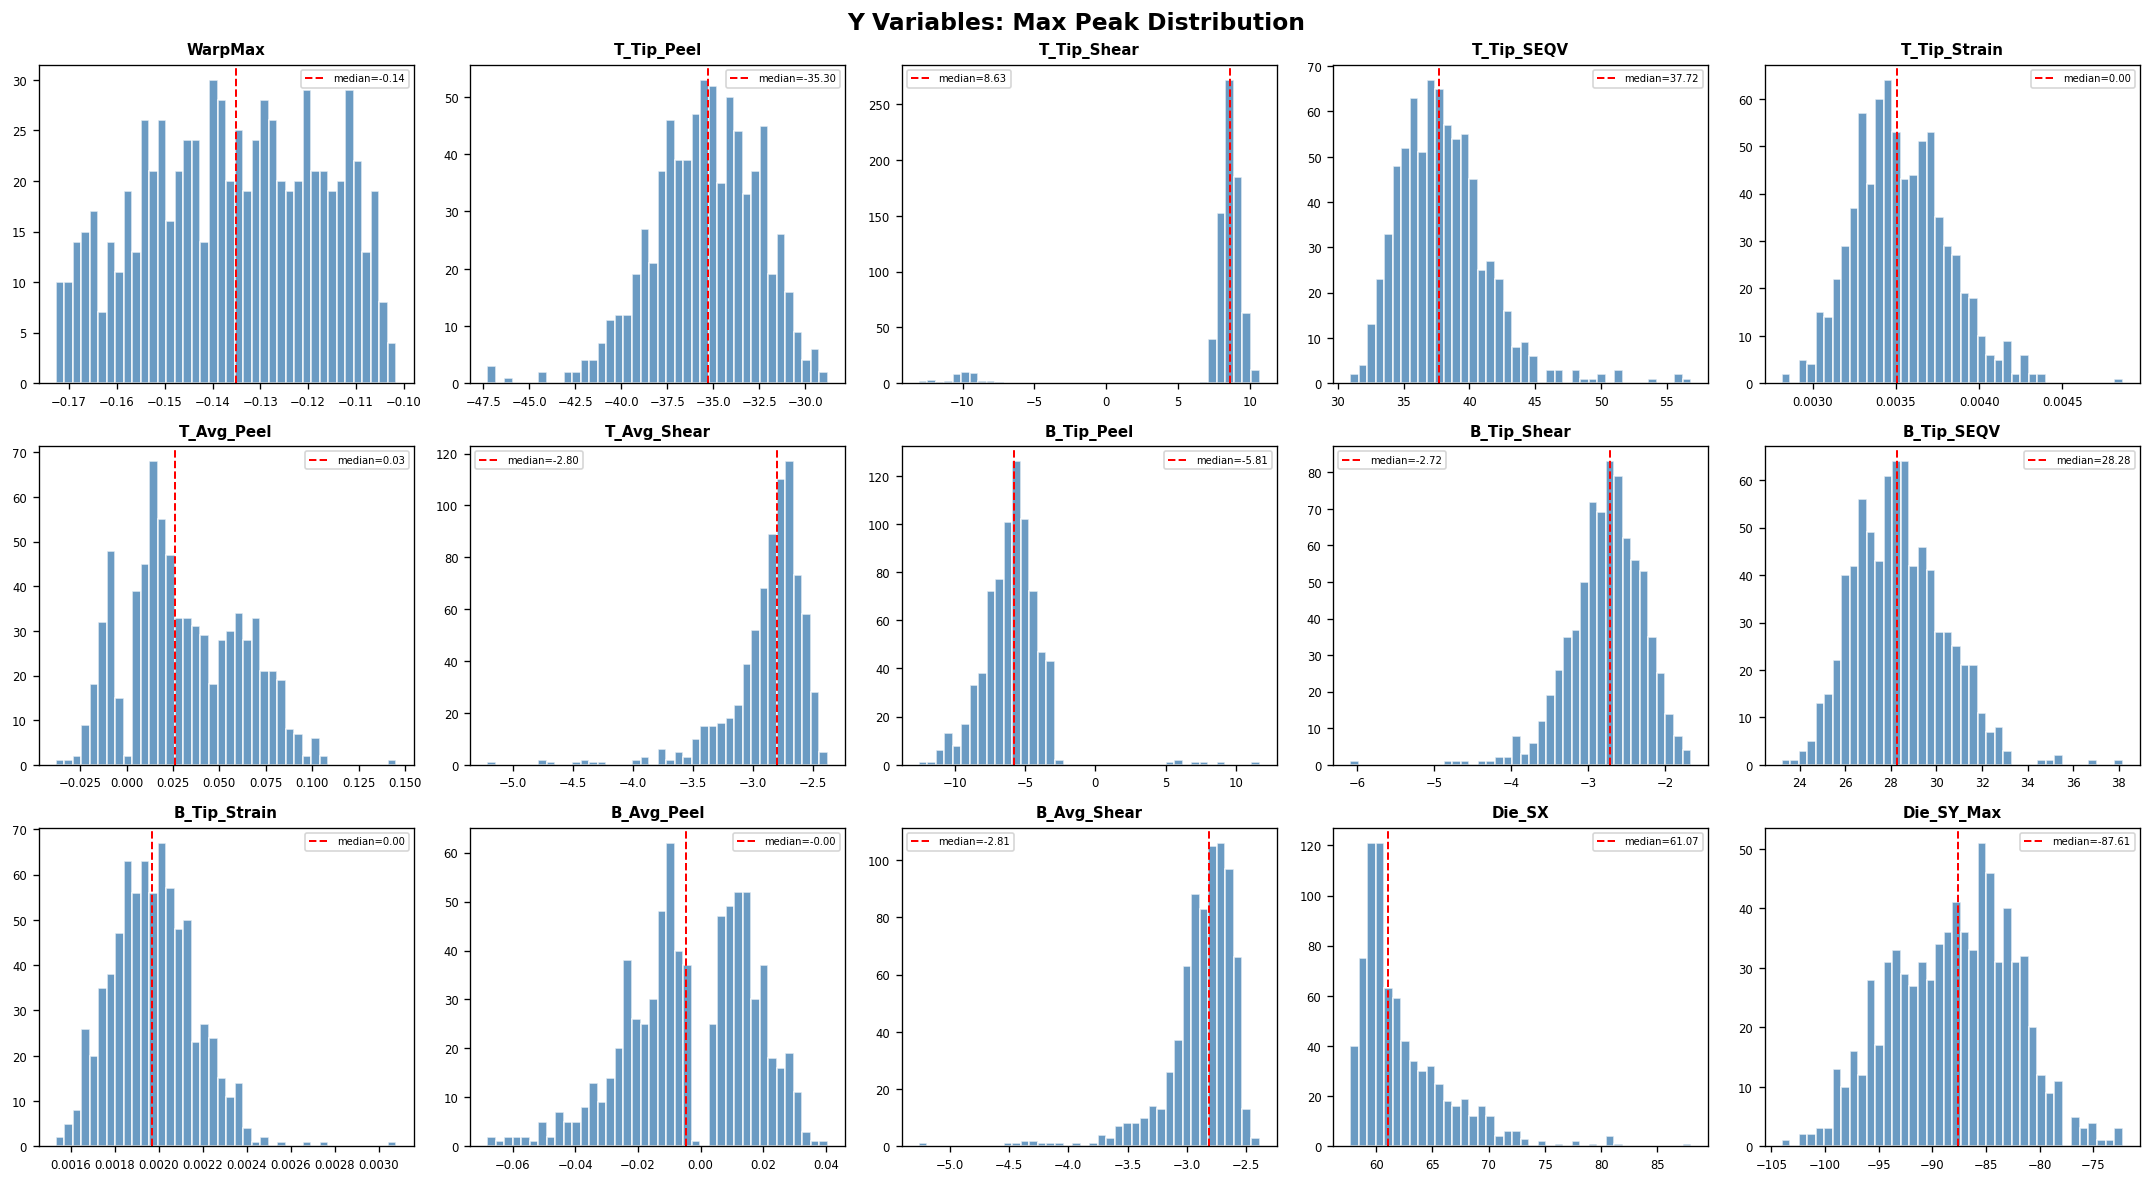

In [39]:
# == 3-2. Y 변수 피크값 분포 히스토그램 ==
# 각 응력/변형 채널의 피크 분포를 확인하여 편향(skew)이나 이상치 진단

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Y Variables: Max Peak Distribution', fontsize=14, fontweight='bold')

for idx, y_col in enumerate(Y_COLUMNS):
    ax = axes[idx // 5, idx % 5]
    data = df_peaks[y_col].dropna()
    
    # 히스토그램 + 중앙값 표시
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linewidth=1.2, linestyle='--',
               label=f'median={data.median():.2f}')
    ax.set_title(y_col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

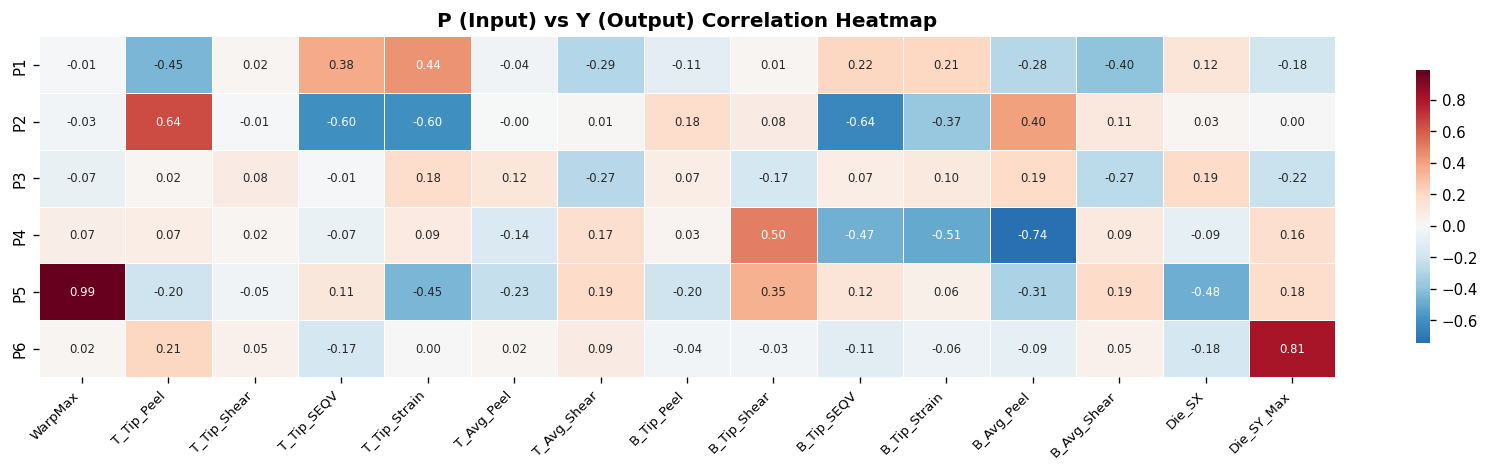


-- |상관계수| > 0.5인 강한 P-Y 관계 --
  P2 -> T_Tip_Peel: r=0.638 (양의 상관)
  P2 -> T_Tip_SEQV: r=-0.596 (음의 상관)
  P2 -> T_Tip_Strain: r=-0.599 (음의 상관)
  P2 -> B_Tip_SEQV: r=-0.637 (음의 상관)
  P4 -> B_Tip_Shear: r=0.503 (양의 상관)
  P4 -> B_Tip_Strain: r=-0.507 (음의 상관)
  P4 -> B_Avg_Peel: r=-0.744 (음의 상관)
  P5 -> WarpMax: r=0.987 (양의 상관)
  P6 -> Die_SY_Max: r=0.811 (양의 상관)


In [40]:
# == 3-3. P(입력) <-> Y(출력) 상관관계 히트맵 ==
# 어떤 두께 변수(P)가 어떤 응력(Y)에 강하게 영향을 미치는지 파악

p_cols = ['P1','P2','P3','P4','P5','P6']
corr_matrix = df_peaks[p_cols + Y_COLUMNS].corr()

# P vs Y 영역만 추출 (6 x 15 부분행렬)
corr_py = corr_matrix.loc[p_cols, Y_COLUMNS]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(corr_py, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('P (Input) vs Y (Output) Correlation Heatmap', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# 상관관계가 강한 P-Y 조합 출력 (|r| > 0.5)
print('\n-- |상관계수| > 0.5인 강한 P-Y 관계 --')
for p in p_cols:
    for y in Y_COLUMNS:
        r = corr_py.loc[p, y]
        if abs(r) > 0.5:
            direction = '양' if r > 0 else '음'
            print(f'  {p} -> {y}: r={r:.3f} ({direction}의 상관)')

---
## 4. XGBoost 대리 모델 학습

### 학습 전략
- **타겟별 개별 XGBoost** 학습 (각 타겟의 하이퍼파라미터를 독립 튜닝 가능)
- **5-Fold Cross Validation**으로 과적합 여부 진단
- **홀드아웃 Test Set (15%)**으로 최종 성능 평가
- **Early Stopping**: validation loss가 20 라운드 연속 개선 안 되면 조기 종료

### 하이퍼파라미터 선정 근거
- `n_estimators=300`: ~900개 중간 규모 데이터에 충분한 앙상블 수
- `max_depth=6`: 6개 입력변수 대비 적절한 트리 깊이
- `learning_rate=0.05`: 보수적 학습률로 과적합 방지
- `subsample/colsample_bytree=0.8`: 랜덤 서브샘플링으로 일반화 향상
- `reg_alpha=0.1, reg_lambda=1.0`: L1/L2 정규화로 복잡도 억제

전체 데이터: 766개 | Train: 651개 | Test: 115개

=== 타겟별 Optuna 최적화 및 XGBoost 학습 시작 ===
--- Optimizing WarpMax ---
  Done! [Best CV R2: 0.9969] [Test R2: 0.9967]
--- Optimizing T_Tip_Peel ---
  Done! [Best CV R2: 0.7124] [Test R2: 0.5752]
--- Optimizing T_Tip_Shear ---
  Done! [Best CV R2: -0.0237] [Test R2: -0.0051]
--- Optimizing T_Tip_SEQV ---
  Done! [Best CV R2: 0.5302] [Test R2: 0.4392]
--- Optimizing T_Tip_Strain ---
  Done! [Best CV R2: 0.6538] [Test R2: 0.6633]
--- Optimizing T_Avg_Peel ---
  Done! [Best CV R2: 0.0464] [Test R2: 0.0525]
--- Optimizing T_Avg_Shear ---
  Done! [Best CV R2: 0.1977] [Test R2: 0.1412]
--- Optimizing B_Tip_Peel ---
  Done! [Best CV R2: 0.1109] [Test R2: 0.0840]
--- Optimizing B_Tip_Shear ---
  Done! [Best CV R2: 0.3711] [Test R2: 0.4293]
--- Optimizing B_Tip_SEQV ---
  Done! [Best CV R2: 0.7792] [Test R2: 0.8059]
--- Optimizing B_Tip_Strain ---
  Done! [Best CV R2: 0.2716] [Test R2: 0.3283]
--- Optimizing B_Avg_Peel ---
  Done! [Best CV R2: 0.8031] [Test R2

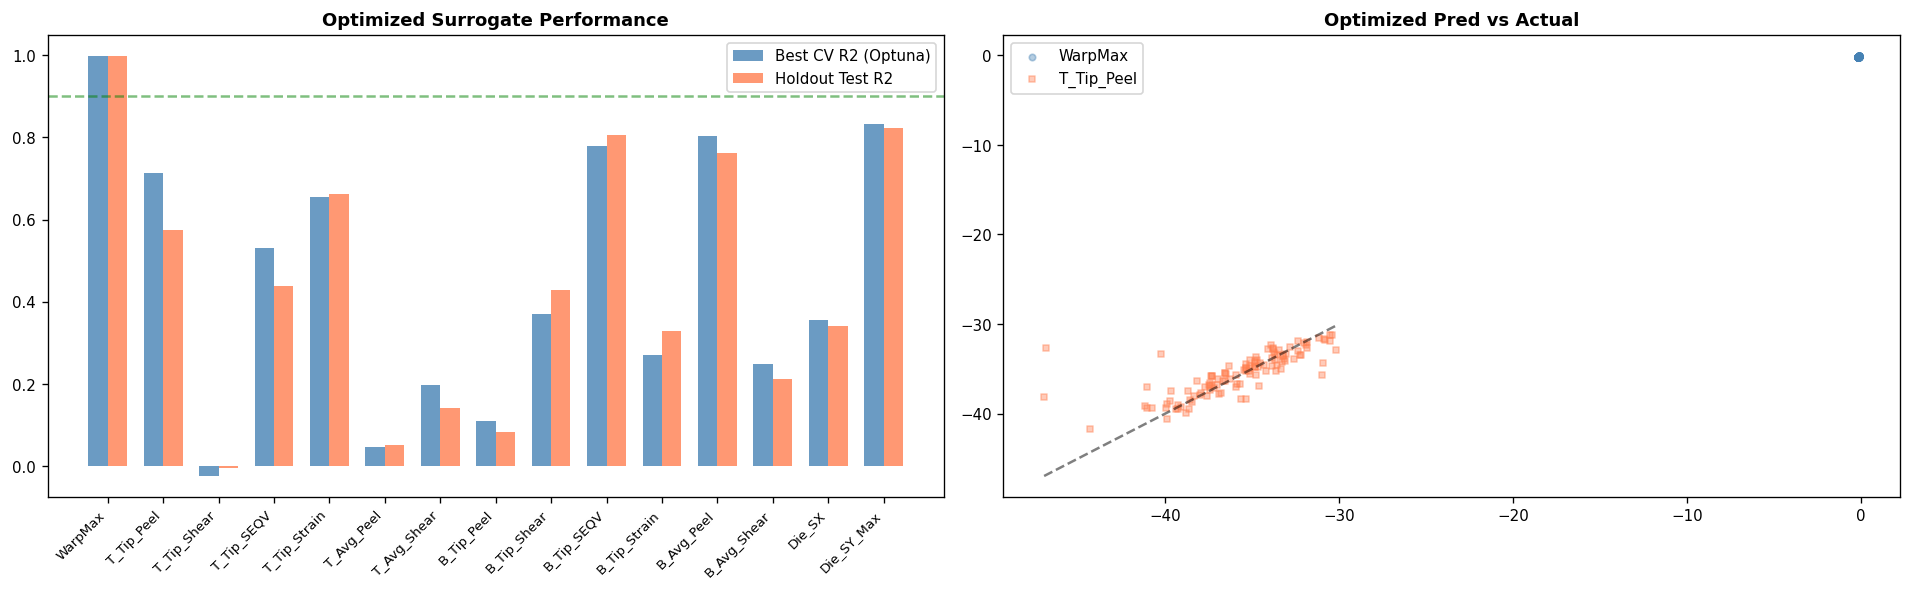

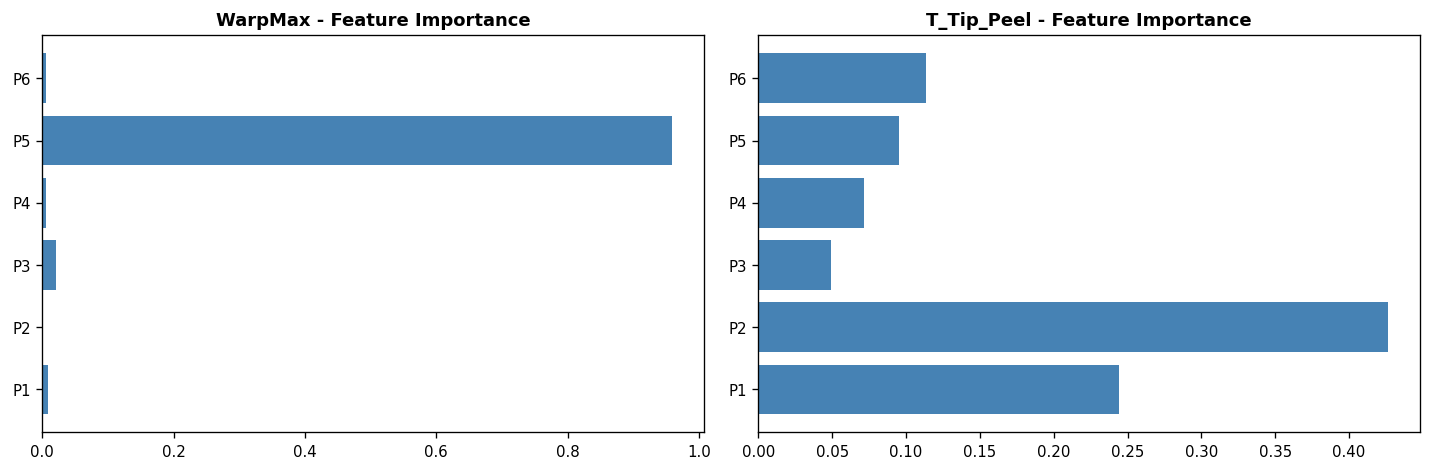

In [41]:
import xgboost as xgb
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import time
import optuna
# Optuna의 내부 로그(Trial 결과 등)를 끄고 에러만 출력하도록 설정
optuna.logging.set_verbosity(optuna.logging.WARNING)

# == 4-1. X / Y 분리 및 Train / Test Split ==
X = df_peaks[['P1','P2','P3','P4','P5','P6']].copy() 
Y = df_peaks[Y_COLUMNS].copy() 

# 최종 성능 평가용 홀드아웃 세트 (15%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=SEED)

print(f'전체 데이터: {len(X)}개 | Train: {len(X_train)}개 | Test: {len(X_test)}개')

# == 4-2. Optuna 목적 함수 정의 (타겟별 최적 파라미터 탐색용) ==
def objective(trial, X_tuning, y_tuning):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': SEED,
        'tree_method': 'hist', # 연산 속도 최적화
        'n_jobs': -1
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    # R2 점수를 최대화하도록 설정
    cv_score = cross_val_score(xgb.XGBRegressor(**param), X_tuning, y_tuning, cv=kf, scoring='r2').mean()
    return cv_score

# == 4-3. 타겟별 개별 최적화 및 학습 수행 ==
models = {}
cv_scores = {}
test_scores = {}
test_maes = {}

print('\n=== 타겟별 Optuna 최적화 및 XGBoost 학습 시작 ===')
t_start = time.time()

for y_col in Y_COLUMNS:
    print(f'--- Optimizing {y_col} ---')
    
    # 1. Optuna Study 수행 (타겟당 30회 시도)
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train, Y_train[y_col]), n_trials=30)
    
    # 2. 최적 파라미터로 최종 모델 정의 및 학습
    # (Early Stopping을 위해 내부에서 다시 Train/Val 분리)
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, Y_train[y_col], test_size=0.15, random_state=SEED)
    
    # [수정 포인트]: early_stopping_rounds를 모델 생성자(XGBRegressor) 안으로 이동
    best_model = xgb.XGBRegressor(
        **study.best_params, 
        #early_stopping_rounds=20, # 모델 선언 시 여기에 넣습니다.
        random_state=SEED
    )
    
    best_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)], # 모니터링 셋은 유지
        verbose=False
    )
    
    # 3. 성능 평가
    y_pred = best_model.predict(X_test)
    models[y_col] = best_model
    cv_scores[y_col] = study.best_value
    test_scores[y_col] = r2_score(Y_test[y_col], y_pred)
    test_maes[y_col] = mean_absolute_error(Y_test[y_col], y_pred)
    
    print(f'  Done! [Best CV R2: {cv_scores[y_col]:.4f}] [Test R2: {test_scores[y_col]:.4f}]')

elapsed = time.time() - t_start
print(f'\n=== 전체 최적화 학습 완료 ({elapsed:.1f}초 소요) ===')

# == 4-4. 결과 시각화 (기존 로직 유지) ==
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (A) 변수별 R2 비교
ax = axes[0]
x_pos = np.arange(len(Y_COLUMNS))
width = 0.35
ax.bar(x_pos - width/2, [cv_scores[c] for c in Y_COLUMNS], width, label='Best CV R2 (Optuna)', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, [test_scores[c] for c in Y_COLUMNS], width, label='Holdout Test R2', color='coral', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(Y_COLUMNS, rotation=45, ha='right', fontsize=8)
ax.set_title('Optimized Surrogate Performance', fontweight='bold')
ax.legend()
ax.axhline(0.9, color='green', linestyle='--', alpha=0.5)

# (B) 메인 타겟 Pred vs Actual
ax = axes[1]
for y_col, color, marker in [('WarpMax', 'steelblue', 'o'), ('T_Tip_Peel', 'coral', 's')]:
    ax.scatter(Y_test[y_col], models[y_col].predict(X_test), alpha=0.4, s=15, c=color, marker=marker, label=y_col)
ax.plot([Y_test[y_col].min(), Y_test[y_col].max()], [Y_test[y_col].min(), Y_test[y_col].max()], 'k--', alpha=0.5)
ax.set_title('Optimized Pred vs Actual', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# (C) Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_col in zip(axes, ['WarpMax', 'T_Tip_Peel']):
    importance = models[y_col].feature_importances_
    ax.barh(['P1','P2','P3','P4','P5','P6'], importance, color='steelblue')
    ax.set_title(f'{y_col} - Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
print(f"실제 데이터 최소값: {Y_test['WarpMax'].min()}")
print(f"AI 예측 데이터 최소값: {models['WarpMax'].predict(X_test).min()}")

실제 데이터 최소값: -0.172226953
AI 예측 데이터 최소값: -0.17133828997612


---
## 5. 몬테카를로 난수 생성 및 10만 개 가상 데이터 증강

학습된 XGBoost 대리 모델로 **10만 개의 가상 P1~P6 조합**에 대한 Y값을 예측합니다.

### 난수 생성 방식: Latin Hypercube Sampling (LHS)
- 단순 `np.random.uniform`보다 6차원 설계 공간을 **더 균일하게 커버**
- 각 차원을 N개 구간으로 분할 후 구간당 1개씩 배치 (층화 샘플링)
- 동일 샘플 수 대비 사각지대(dead zone) 없이 골고루 분포

In [43]:
# == 5-1. Latin Hypercube Sampling (LHS)으로 10만 개 P1~P6 생성 ==

N_VIRTUAL = 100_000  # 생성할 가상 데이터 수

def latin_hypercube_sampling(n_samples, n_dims, seed=42):
    """
    Latin Hypercube Sampling (LHS) 구현
    
    원리:
    - [0, 1] 범위를 n_samples개의 균등 구간으로 분할
    - 각 차원에서 한 구간당 정확히 하나의 샘플을 배치 (층화 샘플링)
    - 차원별로 독립적으로 셔플하여 조합
    
    Parameters:
        n_samples: 생성할 샘플 수
        n_dims: 차원 수 (변수 수)
        seed: 난수 시드
    Returns:
        (n_samples, n_dims) numpy 배열, 값 범위 [0, 1]
    """
    rng = np.random.RandomState(seed)
    result = np.zeros((n_samples, n_dims))
    
    for dim in range(n_dims):
        # 각 구간 내에서의 랜덤 오프셋 생성
        perms = rng.permutation(n_samples)  # 구간 순서 셔플
        # (구간 번호 + 랜덤 오프셋) / 총 구간 수 -> [0, 1] 범위로 정규화
        result[:, dim] = (perms + rng.uniform(size=n_samples)) / n_samples
    
    return result

# [0,1]^6 범위 LHS 생성
lhs_raw = latin_hypercube_sampling(N_VIRTUAL, n_dims=6, seed=SEED)

# 각 P 변수의 실제 min/max 바운더리로 스케일링
# 바운더리는 마스터 DOE 전체 1200개 기준 (생존 데이터가 아닌 원본 전체)
p_cols = ['P1','P2','P3','P4','P5','P6']
virtual_X_dict = {}

print(f'-- {N_VIRTUAL:,}개 가상 P1~P6 생성 (LHS) --')
print(f'{"변수":>5s} | {"Min":>8s} | {"Max":>8s}')
print('-' * 30)

for i, p in enumerate(p_cols):
    lo = df_master[p].min()   # 마스터 DOE 전체의 최솟값
    hi = df_master[p].max()   # 마스터 DOE 전체의 최댓값
    
    # [0,1] -> [min, max] 선형 변환
    virtual_X_dict[p] = lo + (hi - lo) * lhs_raw[:, i]
    print(f'{p:>5s} | {lo:8.4f} | {hi:8.4f}')

df_virtual_X = pd.DataFrame(virtual_X_dict)
print(f'\n{N_VIRTUAL:,}개 가상 P1~P6 조합 생성 완료')
display(df_virtual_X.describe().round(4))

-- 100,000개 가상 P1~P6 생성 (LHS) --
   변수 |      Min |      Max
------------------------------
   P1 |   0.8005 |   1.0998
   P2 |   0.0500 |   0.0899
   P3 |   0.6001 |   0.7198
   P4 |   0.1000 |   0.2994
   P5 |   1.2003 |   1.7997
   P6 |   0.0401 |   0.0800

100,000개 가상 P1~P6 조합 생성 완료


,P1,P2,P3,P4,P5,P6
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,0.9502,0.0699,0.6600,0.1997,1.5000,0.0600
std,0.0864,0.0115,0.0346,0.0576,0.1730,0.0115
min,0.8005,0.0500,0.6001,0.1000,1.2003,0.0401
25%,0.8753,0.0600,0.6300,0.1499,1.3502,0.0501
50%,0.9502,0.0700,0.6599,0.1997,1.5000,0.0600
75%,1.0250,0.0799,0.6899,0.2495,1.6498,0.0700
max,1.0998,0.0899,0.7198,0.2994,1.7997,0.0800


In [44]:
# == 5-2. 대리 모델로 10만 개 Y값 동시 예측 ==

print(f'학습된 XGBoost로 {N_VIRTUAL:,}개의 Y 값 예측 중...')
t_start = time.time()

virtual_Y_dict = {}
for y_col in Y_COLUMNS:
    # 각 타겟별로 학습된 개별 모델로 예측
    virtual_Y_dict[y_col] = models[y_col].predict(df_virtual_X)

df_virtual_Y = pd.DataFrame(virtual_Y_dict)

elapsed = time.time() - t_start
print(f'예측 완료! ({elapsed:.2f}초 소요)')

학습된 XGBoost로 100,000개의 Y 값 예측 중...
예측 완료! (1.20초 소요)


In [45]:
# == 5-3. 예측 결과 물리적 범위 검증 ==
# 대리 모델이 외삽(extrapolation)하여 비현실적인 값을 예측했는지 검증
# 실제 데이터 범위 +- 20% 마진을 허용 범위로 설정

print('=== 예측 데이터 물리적 범위 검증 ===')
print(f'{"변수":15s} | {"실제 Min":>12s} | {"실제 Max":>12s} | '
      f'{"예측 Min":>12s} | {"예측 Max":>12s} | 이탈률')
print('-' * 90)

outlier_flags = pd.Series(False, index=df_virtual_Y.index)

for y_col in Y_COLUMNS:
    actual_min = df_peaks[y_col].min()
    actual_max = df_peaks[y_col].max()
    pred_min = df_virtual_Y[y_col].min()
    pred_max = df_virtual_Y[y_col].max()
    
    # 실제 범위의 20% 마진을 허용 범위로 설정
    margin = (actual_max - actual_min) * 0.20
    safe_lo = actual_min - margin
    safe_hi = actual_max + margin
    
    # 허용 범위를 벗어나는 예측값 탐지
    out_mask = (df_virtual_Y[y_col] < safe_lo) | (df_virtual_Y[y_col] > safe_hi)
    outlier_flags = outlier_flags | out_mask
    n_out = out_mask.sum()
    pct = n_out / len(df_virtual_Y) * 100
    
    flag = '  <<' if pct > 5 else ''
    print(f'{y_col:15s} | {actual_min:12.4f} | {actual_max:12.4f} | '
          f'{pred_min:12.4f} | {pred_max:12.4f} | {pct:5.2f}%{flag}')

n_outlier = outlier_flags.sum()
print(f'\n범위 이탈 샘플 총합: {n_outlier:,}개 ({n_outlier/len(df_virtual_Y)*100:.2f}%)')
print('(이탈 샘플이 많으면 모델 과적합 또는 외삽 위험)')
print('-> Step 2 Gatekeeper 분류기에서 물리적으로 불안전한 조합은 추가 필터링 예정')

=== 예측 데이터 물리적 범위 검증 ===
변수              |       실제 Min |       실제 Max |       예측 Min |       예측 Max | 이탈률
------------------------------------------------------------------------------------------
WarpMax         |      -0.1728 |      -0.1015 |      -0.1732 |      -0.1022 |  0.00%
T_Tip_Peel      |     -47.2917 |     -28.7603 |     -43.5057 |     -28.9188 |  0.00%
T_Tip_Shear     |     -13.0566 |      10.6679 |      -0.8194 |       8.6022 |  0.00%
T_Tip_SEQV      |      30.9377 |      56.8349 |      32.4816 |      46.0688 |  0.00%
T_Tip_Strain    |       0.0028 |       0.0049 |       0.0032 |       0.0039 |  0.00%
T_Avg_Peel      |      -0.0382 |       0.1454 |       0.0043 |       0.0502 |  0.00%
T_Avg_Shear     |      -5.2160 |      -2.3780 |      -3.5515 |      -2.5971 |  0.00%
B_Tip_Peel      |     -12.5674 |      11.6636 |     -10.0703 |      -0.9972 |  0.00%
B_Tip_Shear     |      -6.0878 |      -1.6600 |      -4.2268 |      -1.8078 |  0.00%
B_Tip_SEQV      |      23.2101 |     

In [46]:
# == 5-4. 증강 데이터 병합 및 CSV 저장 ==

# X(입력: P1~P6)와 예측된 Y(출력: 15개 응력/변형 피크) 병합
df_augmented = pd.concat([df_virtual_X, df_virtual_Y], axis=1)

# 가상 데이터 식별용 ID 부여 (원본과 구분)
df_augmented.insert(0, 'Row_ID', [f'Virtual_{i+1}' for i in range(N_VIRTUAL)])

# CSV 저장
output_file = 'Augmented_100k_Data.csv'
df_augmented.to_csv(output_file, index=False)

print(f'=== 증강 데이터 저장 완료 ===')
print(f'파일명: {output_file}')
print(f'크기: {df_augmented.shape[0]:,}행 x {df_augmented.shape[1]}열')
print(f'컬럼: Row_ID + P1~P6 (6) + Y변수 ({len(Y_COLUMNS)}) = {1+6+len(Y_COLUMNS)}열')
print()
display(df_augmented.head())

=== 증강 데이터 저장 완료 ===
파일명: Augmented_100k_Data.csv
크기: 100,000행 x 22열
컬럼: Row_ID + P1~P6 (6) + Y변수 (15) = 22열



,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,Virtual_1,1.027135,0.087445,0.658718,0.231420,1.685991,0.052563,-0.115699,-35.046772,2.695023,...,0.009670,-2.934123,-5.897428,-2.258545,26.246988,0.001900,-0.018463,-2.939885,62.636261,-89.142746
1,Virtual_2,1.040493,0.076397,0.628455,0.214296,1.579394,0.077707,-0.124040,-34.509342,7.895330,...,0.022816,-2.775192,-6.024335,-2.448780,26.770126,0.001900,-0.025157,-2.844323,59.626492,-82.224121
2,Virtual_3,0.859955,0.086767,0.655392,0.189343,1.779187,0.066959,-0.104942,-31.917303,7.312047,...,0.017885,-2.757373,-5.966919,-2.632508,26.470188,0.001918,-0.002567,-2.684622,60.184093,-81.849236
3,Virtual_4,1.030061,0.065772,0.626600,0.236199,1.400582,0.046464,-0.144514,-37.331066,7.582466,...,0.026861,-2.856380,-5.553951,-2.460753,27.764395,0.001922,-0.029222,-3.021365,62.044727,-96.799583
4,Virtual_5,1.078823,0.057586,0.608553,0.295215,1.325479,0.077874,-0.150745,-36.348721,7.894830,...,0.027731,-2.833557,-6.744345,-2.562689,27.814749,0.001943,-0.038563,-2.883071,61.603745,-81.886444


---
## 6. 증강 데이터 품질 검증 (Sanity Check)

증강된 10만 개 데이터의 분포가 원본 ~900개와 일관성이 있는지 시각적으로 검증합니다.

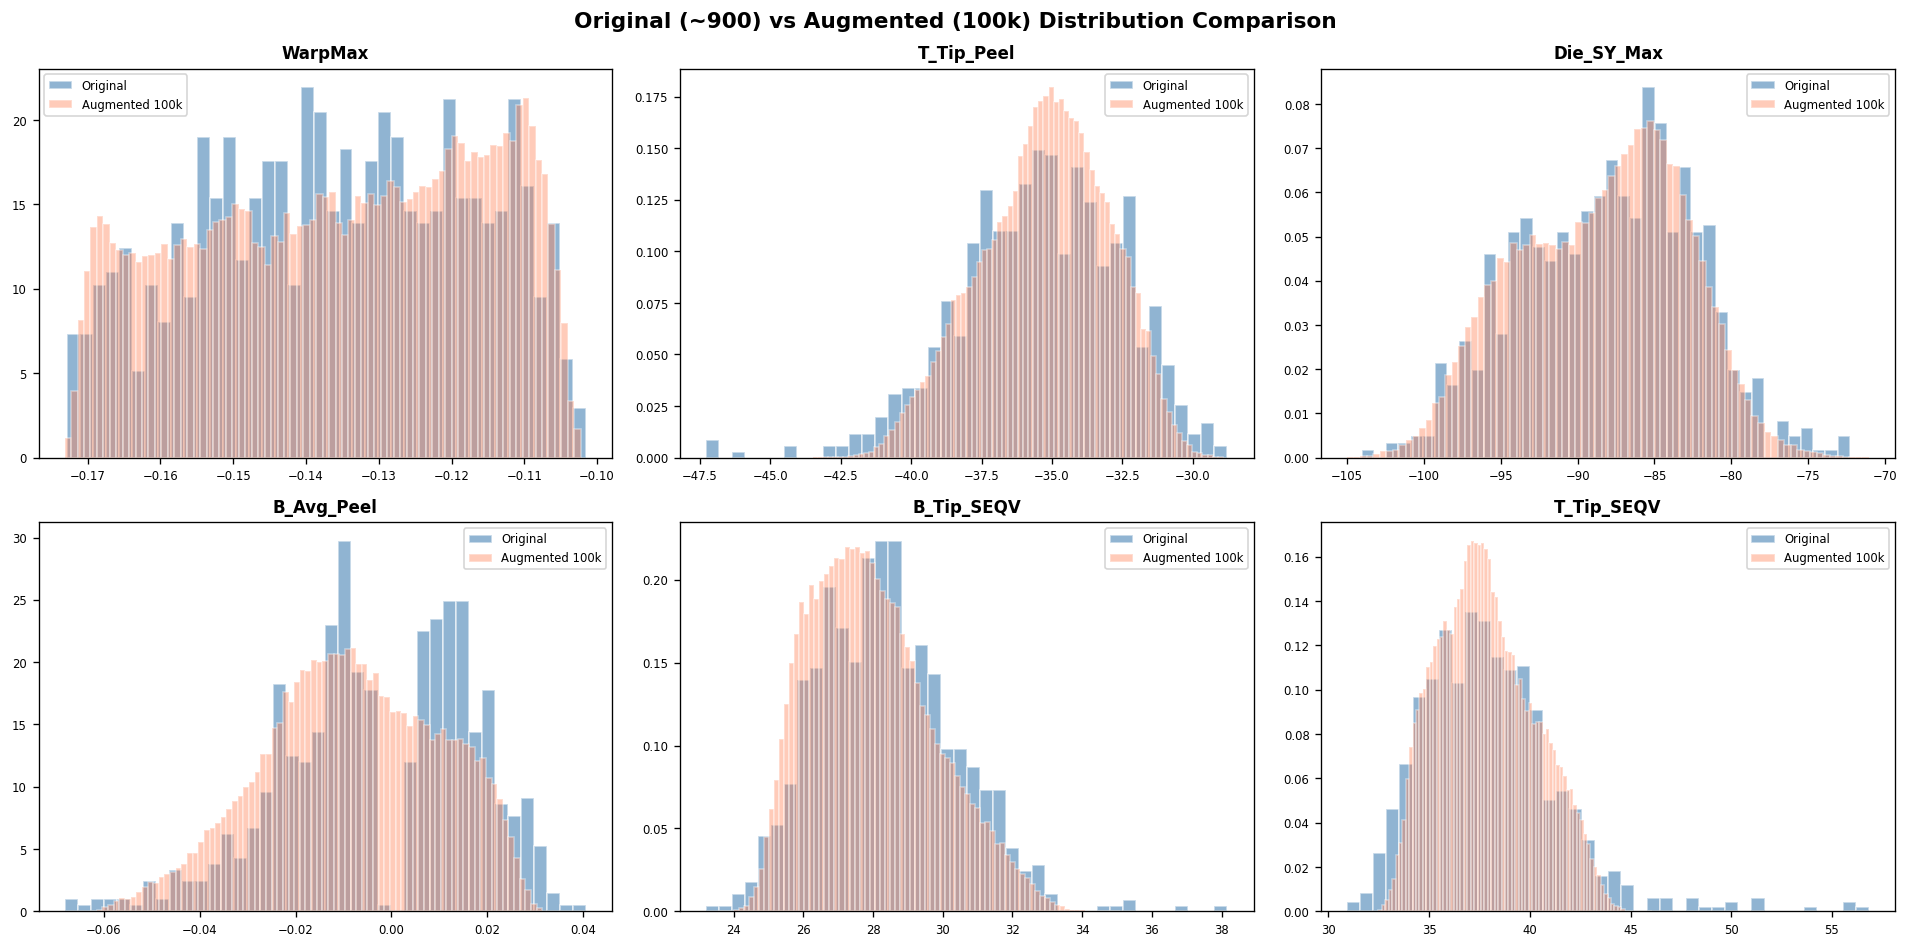

* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것
* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요


In [47]:
# == 6-1. 원본 vs 증강 분포 비교 (주요 6개 변수) ==

check_cols = ['WarpMax', 'T_Tip_Peel', 'Die_SY_Max', 
              'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_SEQV']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Original (~900) vs Augmented (100k) Distribution Comparison',
             fontsize=13, fontweight='bold')

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 원본 데이터 분포 (파란색 히스토그램)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', label='Original')
    
    # 증강 데이터 분포 (빨간색 히스토그램, 더 세밀한 bin)
    ax.hist(df_augmented[y_col], bins=80, density=True, alpha=0.4,
            color='coral', edgecolor='white', label='Augmented 100k')
    
    ax.set_title(y_col, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

print('* 분포가 대체로 일치하면 -> 대리 모델이 원본 경향을 잘 학습한 것')
print('* 분포가 크게 다르면 -> 과적합/외삽 위험 -> 하이퍼파라미터 재조정 필요')

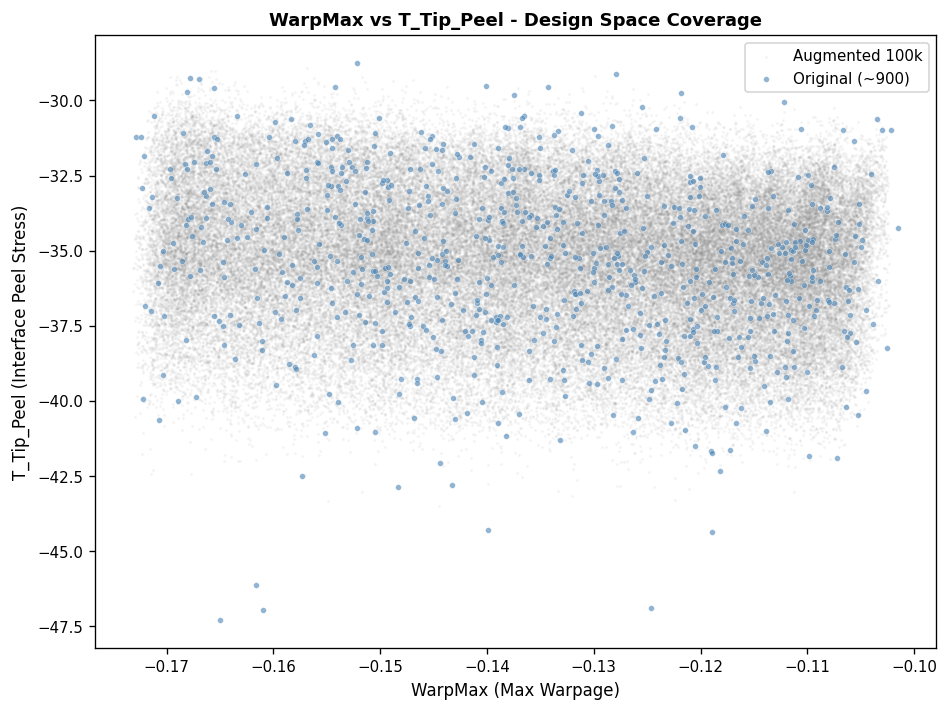

-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계
-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역


In [48]:
# == 6-2. 메인 타겟 2D 산점도 (WarpMax vs T_Tip_Peel) ==
# Step 3 파레토 프론티어에서 사용할 두 축의 공간 분포 확인

fig, ax = plt.subplots(figsize=(8, 6))

# 증강 데이터 (배경: 회색, 매우 투명하게)
ax.scatter(df_augmented['WarpMax'], df_augmented['T_Tip_Peel'],
           s=1, alpha=0.05, c='gray', label='Augmented 100k')

# 원본 데이터 (전경: 파란색, 선명하게)
ax.scatter(df_peaks['WarpMax'], df_peaks['T_Tip_Peel'],
           s=12, alpha=0.6, c='steelblue', edgecolors='white',
           linewidths=0.3, label='Original (~900)')

ax.set_xlabel('WarpMax (Max Warpage)', fontsize=10)
ax.set_ylabel('T_Tip_Peel (Interface Peel Stress)', fontsize=10)
ax.set_title('WarpMax vs T_Tip_Peel - Design Space Coverage', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계')
print('-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역')

---
## Step 1 완료 요약

| 항목 | 결과 |
|------|------|
| 원본 생존 데이터 | ~900개 DP (1200 중 ~71%) |
| 추출 지표 | 15개 Y변수의 절댓값 Max Peak (부호 유지) |
| 대리 모델 | 타겟별 개별 XGBoost (Early Stopping + 5-Fold CV) |
| 증강 데이터 | **100,000개** (`Augmented_100k_Data.csv`) |
| 난수 생성 | Latin Hypercube Sampling (균등 공간 충전) |

### 다음 단계
-> **[Step 2: Gatekeeper 분류기]** 에서 증강된 10만 개 중 '물리적으로 파괴되는 조합'을 필터링합니다.

In [49]:
import platform

# Step 1 증강 데이터 입력 / Step 2 필터링 결과 출력 (절대 경로 통일)
AUGMENTED_INPUT  = 'Augmented_100k_Data.csv'
FILTERED_OUTPUT  = 'Augmented_Class_Data.csv'

SEED = 42
np.random.seed(SEED)

print('=== [Step 2] Gatekeeper 분류기 가동 준비 완료 ===')
print(f'현재 감지된 OS  : {platform.system()}')
print(f'시계열 CSV 폴더 : {CSV_FOLDER}')
print(f'마스터 DOE 파일 : {MASTER_CSV}')
print(f'증강 데이터 입력: {AUGMENTED_INPUT}')
print(f'필터링 결과 출력: {FILTERED_OUTPUT}\n')

=== [Step 2] Gatekeeper 분류기 가동 준비 완료 ===
현재 감지된 OS  : Windows
시계열 CSV 폴더 : C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS/data
마스터 DOE 파일 : Master_DOE_1200.csv
증강 데이터 입력: Augmented_100k_Data.csv
필터링 결과 출력: Augmented_Class_Data.csv



In [50]:
# ====================================================================
# [2. 실제 해석 결과 기반 생존/파탄 라벨링]
# ====================================================================
# glob으로 해당 폴더의 모든 CSV 파일 탐색
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

# 파일명에서 Row_ID 추출
survived_ids = set()
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.add(int(match.group(1)))

if not survived_ids:
    raise FileNotFoundError("지정된 경로에서 CSV 파일을 하나도 찾지 못했습니다.")

# 마스터 DOE 데이터 로드
try:
    df_master = pd.read_csv(MASTER_CSV)
except FileNotFoundError:
    raise FileNotFoundError(f"마스터 파일을 찾을 수 없습니다: {MASTER_CSV}")

# 전체 DP 수 = 폴더 내 최대 Row_ID (단, 마스터 DOE 행 수 초과 방지)
max_row_id = min(max(survived_ids), len(df_master))
print(f"라벨링 범위: Row_ID 1 ~ {max_row_id} (마스터 DOE {len(df_master)}행 중)")

# 1번부터 max_row_id까지 라벨링
# Row_ID=1 → df_master.iloc[0] (CSV 1행은 헤더, 2행부터 데이터)
training_data = []
for row_id in range(1, max_row_id + 1):
    idx = row_id - 1  # 0-based 인덱스

    if idx >= len(df_master):
        print(f'[경고] Row_ID={row_id}가 마스터 DOE 범위를 초과 → 스킵')
        continue

    # 생존 여부: 폴더에 해당 CSV가 있으면 1(Safe), 없으면 0(Fail)
    is_safe = 1 if row_id in survived_ids else 0

    row_data = df_master.iloc[idx].to_dict()
    row_data['Row_ID'] = row_id
    row_data['is_safe'] = is_safe
    training_data.append(row_data)

df_train = pd.DataFrame(training_data)

n_total = len(df_train)
n_safe  = df_train['is_safe'].sum()
n_fail  = n_total - n_safe

print(f"학습 데이터: 총 {n_total}개 | 생존(Safe) {n_safe}개 ({n_safe/n_total*100:.1f}%) | 파탄(Fail) {n_fail}개 ({n_fail/n_total*100:.1f}%)\n")

라벨링 범위: Row_ID 1 ~ 1041 (마스터 DOE 1200행 중)
학습 데이터: 총 1041개 | 생존(Safe) 766개 (73.6%) | 파탄(Fail) 275개 (26.4%)



In [51]:
from sklearn.model_selection import StratifiedKFold

# ====================================================================
# [3. Random Forest Gatekeeper 모델 학습 + 성능 평가]
# ====================================================================
X_train = df_train[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']]
y_train = df_train['is_safe']

# -- 3-1. 5-Fold Stratified CV로 성능 사전 평가 --
# Stratified: 클래스 비율(Safe/Fail)을 각 Fold에서 동일하게 유지
gatekeeper_cv = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    class_weight='balanced',  # 클래스 불균형 해소
    random_state=SEED
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1 = cross_val_score(gatekeeper_cv, X_train, y_train, cv=skf, scoring='f1')
cv_acc = cross_val_score(gatekeeper_cv, X_train, y_train, cv=skf, scoring='accuracy')

print('-- 5-Fold Stratified CV 성능 --')
print(f'  F1 Score : {cv_f1.mean():.4f} (+-{cv_f1.std():.4f})')
print(f'  Accuracy : {cv_acc.mean():.4f} (+-{cv_acc.std():.4f})')

# -- 3-2. 전체 데이터로 최종 학습 (OOB 평가 포함) --
gatekeeper = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    class_weight='balanced',
    oob_score=True,   # Out-of-Bag 스코어로 보조 검증
    random_state=SEED
)

print("\nRandom Forest Gatekeeper 학습 중...")
gatekeeper.fit(X_train, y_train)
print(f"학습 완료. OOB Accuracy: {gatekeeper.oob_score_:.4f}")

# -- 3-3. Feature Importance (어떤 P가 파탄에 가장 큰 영향?) --
print('\n-- Feature Importance (파탄 예측 기여도) --')
importances = gatekeeper.feature_importances_
for col, imp in sorted(zip(['P1','P2','P3','P4','P5','P6'], importances),
                        key=lambda x: x[1], reverse=True):
    bar = '#' * int(imp * 50)
    print(f'  {col}: {imp:.4f} {bar}')


-- 5-Fold Stratified CV 성능 --
  F1 Score : 0.8393 (+-0.0195)
  Accuracy : 0.7474 (+-0.0292)

Random Forest Gatekeeper 학습 중...
학습 완료. OOB Accuracy: 0.7426

-- Feature Importance (파탄 예측 기여도) --
  P5: 0.2655 #############
  P3: 0.1966 #########
  P1: 0.1523 #######
  P4: 0.1473 #######
  P6: 0.1281 ######
  P2: 0.1101 #####


In [52]:
# ====================================================================
# [4. 증강 데이터(10만 개) 필터링]
# ====================================================================
try:
    df_aug = pd.read_csv(AUGMENTED_INPUT)
except FileNotFoundError:
    raise FileNotFoundError(f"Step 1에서 생성된 '{AUGMENTED_INPUT}' 파일을 찾을 수 없습니다.")

print(f"\n{len(df_aug):,}개의 가상 증강 데이터 필터링을 시작합니다.")

# P1~P6 추출 후 Gatekeeper로 0/1 이진 판정
X_aug = df_aug[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']]
aug_preds = gatekeeper.predict(X_aug)

fail_count = (aug_preds == 0).sum()
safe_count = (aug_preds == 1).sum()
total_count = len(aug_preds)

print("-" * 50)
print(f"  Safe(1) : {safe_count:,}개 ({safe_count/total_count*100:.2f}%)")
print(f"  Fail(0) : {fail_count:,}개 ({fail_count/total_count*100:.2f}%) → 삭제 대상")
print("-" * 50)


100,000개의 가상 증강 데이터 필터링을 시작합니다.
--------------------------------------------------
  Safe(1) : 83,192개 (83.19%)
  Fail(0) : 16,808개 (16.81%) → 삭제 대상
--------------------------------------------------


In [53]:
# ====================================================================
# [5. Fail 행 제거 및 저장]
# ====================================================================
# Fail(0)인 행 제거, Safe(1)만 남김
df_aug_filtered = df_aug[aug_preds == 1].reset_index(drop=True)

df_aug_filtered.to_csv(FILTERED_OUTPUT, index=False)

print(f"\n결측치 제거 완료!")
print(f"  입력: {total_count:,}개 → 출력: {len(df_aug_filtered):,}개")
print(f"  저장: {FILTERED_OUTPUT}")
print("이 데이터는 [Step 3: 파레토 타겟 추출]의 베이스라인으로 사용됩니다.")



결측치 제거 완료!
  입력: 100,000개 → 출력: 83,192개
  저장: Augmented_Class_Data.csv
이 데이터는 [Step 3: 파레토 타겟 추출]의 베이스라인으로 사용됩니다.



766개 생존 CSV에서 Max Peak 추출 시작 (시각화 비교용)...

=== Max Peak 추출 완료 ===
성공: 766개 / 실패: 0개 / 소요시간: 2.5초


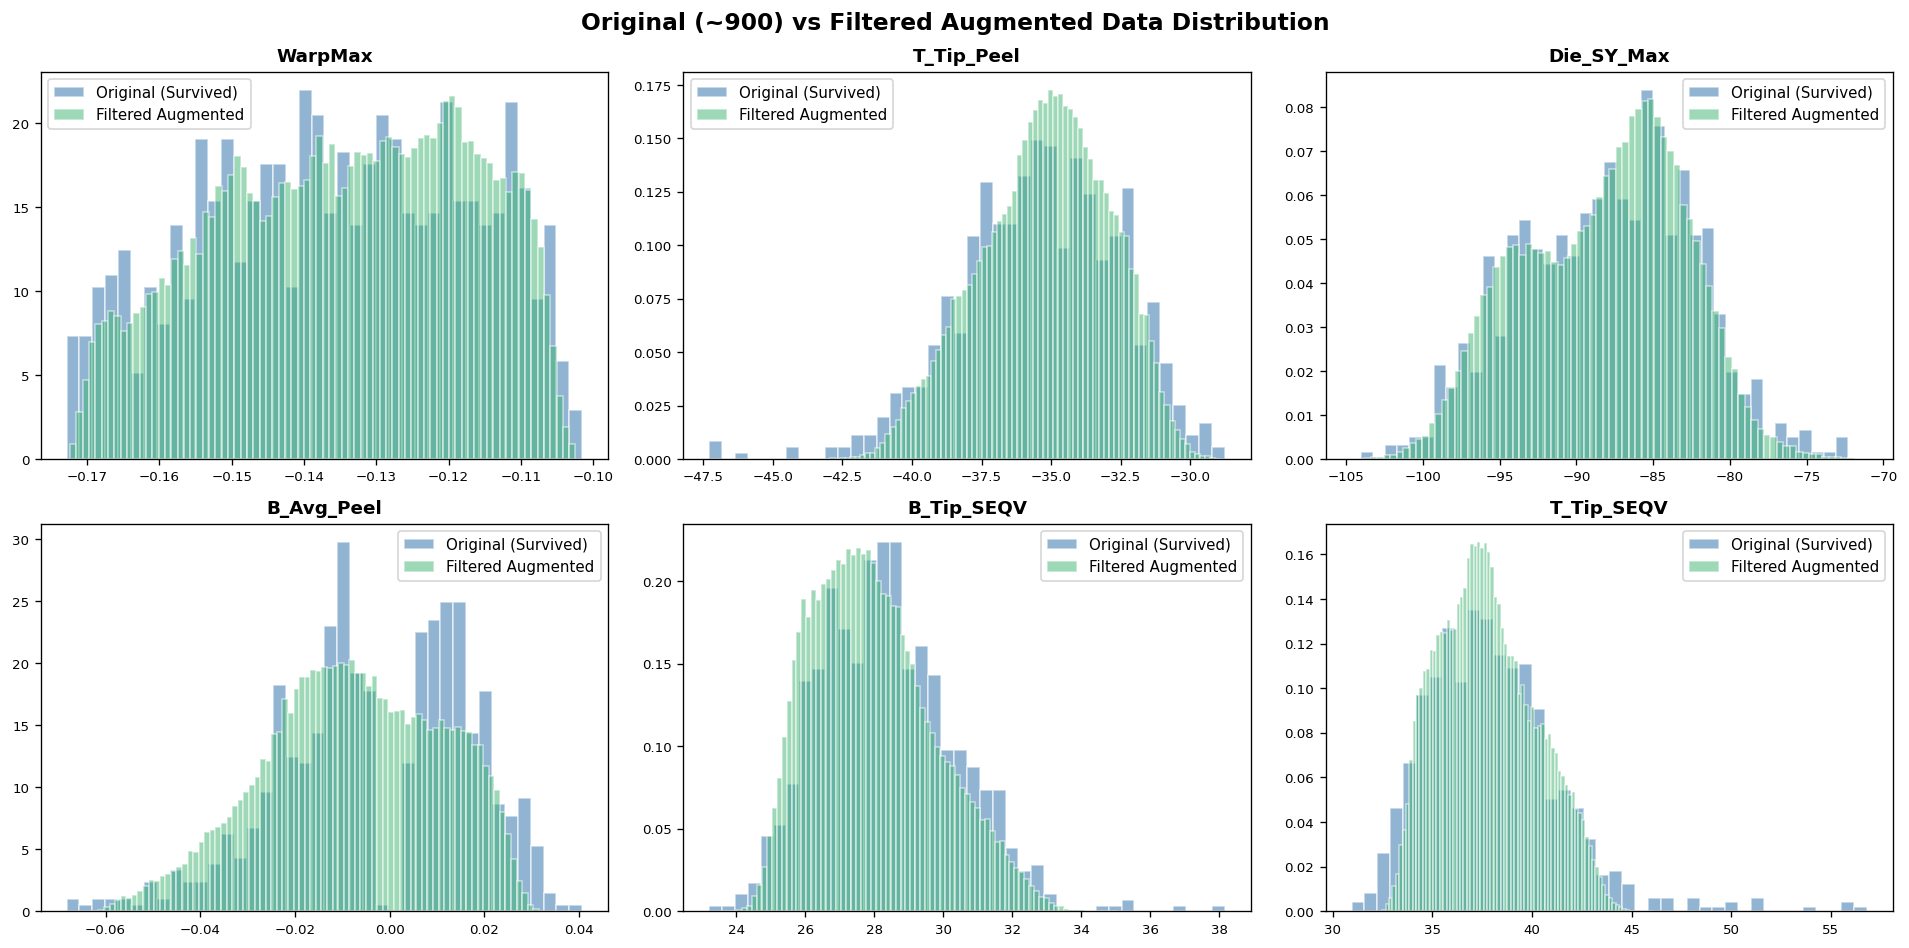

In [54]:
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====================================================================
# [6. 원본 데이터(df_peaks) 즉석 추출 로직 - 수정판]
# ====================================================================
valid_data = []     # 정상 추출된 데이터를 누적할 리스트
error_rows = []     # 읽기 오류가 발생한 Row_ID를 기록할 리스트

t_start = time.time()
print(f'\n{len(survived_ids)}개 생존 CSV에서 Max Peak 추출 시작 (시각화 비교용)...')

for i, row_id in enumerate(survived_ids):
    # 시계열 CSV 파일 경로 구성
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 시계열 데이터 로드 
        df_ts = pd.read_csv(fpath)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 결과 딕셔너리 초기화
        peak_dict = {'Row_ID': row_id}
        
        # 마스터 DOE에서 해당 Row의 P1~P6 가져오기 (인덱스 기반 매칭)
        # Row_ID 1 = 인덱스 0
        idx = row_id - 1 
        for p_col in ['P1','P2','P3','P4','P5','P6']:
            peak_dict[p_col] = df_master.loc[idx, p_col]
        
        # === 핵심 로직: 각 Y 채널별 '절댓값 최대 피크(부호 유지)' 추출 ===
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                max_abs_idx = df_ts[y_col].abs().idxmax()
                peak_dict[y_col] = df_ts.loc[max_abs_idx, y_col]
            else:
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))

elapsed = time.time() - t_start

# 결과 취합
df_peaks = pd.DataFrame(valid_data)

print(f'\n=== Max Peak 추출 완료 ===')
print(f'성공: {len(df_peaks)}개 / 실패: {len(error_rows)}개 / 소요시간: {elapsed:.1f}초')

# 방어 코드: 추출 성공 데이터가 없을 경우 에러 방지
if df_peaks.empty:
    raise ValueError("추출된 데이터가 0개입니다. 경로 설정이나 마스터 파일 인덱스를 확인하세요.")

# NaN이 있는 행 확인 및 제거
nan_count = df_peaks[Y_COLUMNS].isnull().any(axis=1).sum()
if nan_count > 0:
    print(f'[경고] {nan_count}개 행에 NaN 존재 -> 해당 행 제거')
    df_peaks = df_peaks.dropna(subset=Y_COLUMNS).reset_index(drop=True)

# ====================================================================
# [7. 원본 vs Gatekeeper 필터링 완료 증강 데이터 분포 시각화]
# ====================================================================
# Step 2에서 방금 저장한 '분류 이후의 안전한 데이터셋' 로드
filtered_csv_path = 'Augmented_Class_Data.csv'
df_augmented_filtered = pd.read_csv(filtered_csv_path)

# 시각화할 6대 핵심 채널 (노이즈 배제)
check_cols = ['WarpMax', 'T_Tip_Peel', 'Die_SY_Max', 
              'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_SEQV']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Original (~900) vs Filtered Augmented Data Distribution',
             fontsize=14, fontweight='bold')

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 원본 데이터 분포 (파란색 히스토그램)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.6,
            color='steelblue', edgecolor='white', label='Original (Survived)')
    
    # Gatekeeper를 통과한 고품질 증강 데이터 분포 (녹색 히스토그램)
    ax.hist(df_augmented_filtered[y_col], bins=80, density=True, alpha=0.5,
            color='mediumseagreen', edgecolor='white', label='Filtered Augmented')
    
    ax.set_title(y_col, fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


In [59]:
# ====================================================================
# [1. 환경 및 타겟 설정]
# ====================================================================
CORE_7_CHANNELS = [
    'WarpMax', 'Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV', 
    'T_Tip_Strain', 'T_Tip_Peel', 'T_Tip_SEQV'
]

UTOPIA_RATIO = 0.90 
TENSOR_DIR = os.path.join(BASE_DIR, 'Utopia_Target_Tensors')  # 절대 경로 통일
os.makedirs(TENSOR_DIR, exist_ok=True)

print("=== [Step 3] 파레토 비지배 정렬 및 유토피아 타겟 추출 ===")

# ====================================================================
# [2. 다단계 Pareto Non-dominated Sorting (Frontier 0 + 1 + ...)]
# ====================================================================
obj1 = df_peaks['WarpMax'].abs().values
obj2 = df_peaks['T_Tip_Peel'].abs().values
scores = np.column_stack((obj1, obj2))

population_size = scores.shape[0]

# 다단계 비지배 정렬: Frontier 0, 1, 2, ... 순서로 계층 분류
# Frontier 0 = 최상위 (아무에게도 지배 안 당함)
# Frontier 1 = Frontier 0 제거 후 비지배 해
# ...반복
frontier_labels = np.full(population_size, -1, dtype=int)  # 각 DP의 Frontier 등급
remaining = np.ones(population_size, dtype=bool)             # 아직 분류 안 된 DP
frontier_level = 0

while remaining.any():
    remaining_idx = np.where(remaining)[0]
    current_scores = scores[remaining_idx]
    is_pareto = np.ones(len(remaining_idx), dtype=bool)
    
    for i in range(len(remaining_idx)):
        for j in range(len(remaining_idx)):
            if i == j:
                continue
            # j가 i를 지배하는지 판정
            if all(current_scores[j] <= current_scores[i]) and any(current_scores[j] < current_scores[i]):
                is_pareto[i] = False
                break
    
    # 현재 Frontier에 해당하는 DP에 등급 부여
    for k, idx in enumerate(remaining_idx):
        if is_pareto[k]:
            frontier_labels[idx] = frontier_level
            remaining[idx] = False
    
    print(f'  Frontier {frontier_level}: {is_pareto.sum()}개')
    frontier_level += 1
    
    # 안전 장치: 최대 10단계까지만
    if frontier_level >= 10:
        break

# Frontier 등급을 df_peaks에 추가
df_peaks['frontier'] = frontier_labels

# === 파레토 상위 N% 또는 최소 수량 확보 ===
MIN_PARETO_COUNT = 30  # 최소 확보 목표 (Step 4 학습에 필요한 하한)

# Frontier 0부터 순서대로 누적하여 최소 수량 충족될 때까지 확장
selected_frontiers = []
cumulative = 0
for level in range(frontier_level):
    count_at_level = (frontier_labels == level).sum()
    selected_frontiers.append(level)
    cumulative += count_at_level
    if cumulative >= MIN_PARETO_COUNT:
        break

df_pareto = df_peaks[df_peaks['frontier'].isin(selected_frontiers)].copy()
num_pareto = len(df_pareto)
max_frontier = max(selected_frontiers)

print(f'\n총 {population_size}개 중 파레토 Frontier 0~{max_frontier}: {num_pareto}개 ({num_pareto/population_size*100:.1f}%)')
print(f'  (Frontier 0만: {(frontier_labels==0).sum()}개 → 부족하여 Frontier {max_frontier}까지 확장)')

if num_pareto < MIN_PARETO_COUNT:
    print(f'[경고] {num_pareto}개로 목표({MIN_PARETO_COUNT})에 미달. 가용 데이터 전부 사용.')

=== [Step 3] 파레토 비지배 정렬 및 유토피아 타겟 추출 ===
  Frontier 0: 8개
  Frontier 1: 13개
  Frontier 2: 11개
  Frontier 3: 14개
  Frontier 4: 18개
  Frontier 5: 15개
  Frontier 6: 22개
  Frontier 7: 19개
  Frontier 8: 28개
  Frontier 9: 29개

총 766개 중 파레토 Frontier 0~2: 32개 (4.2%)
  (Frontier 0만: 8개 → 부족하여 Frontier 2까지 확장)


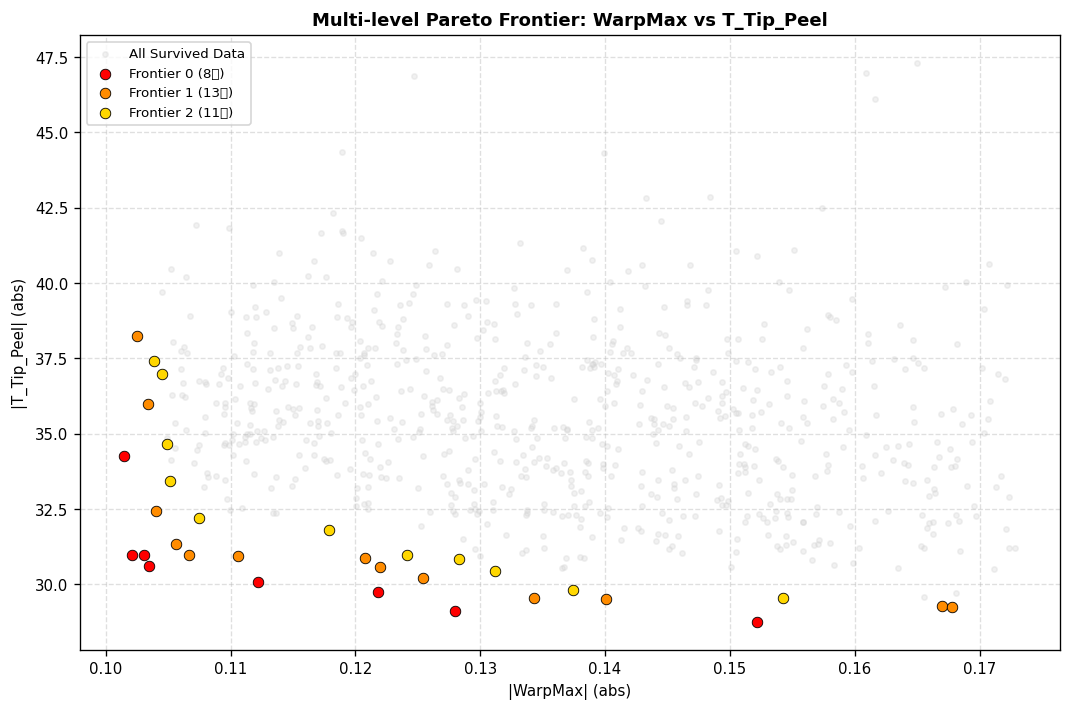

→ 빨간색(Frontier 0)에 가까울수록 WarpMax와 T_Tip_Peel이 동시에 작은 우수 설계
→ 총 32개의 유토피아 타겟 텐서가 Step 4로 전달됨


In [60]:
# ====================================================================
# [3. 다단계 파레토 프론티어 시각화]
# ====================================================================
plt.figure(figsize=(9, 6))

# 전체 데이터 (회색 배경)
plt.scatter(obj1, obj2, color='lightgray', alpha=0.3, s=10, label='All Survived Data')

# Frontier 등급별 색상 구분
colors = ['red', 'darkorange', 'gold', 'limegreen', 'deepskyblue']
for level in selected_frontiers:
    mask = frontier_labels == level
    n = mask.sum()
    c = colors[level] if level < len(colors) else 'gray'
    plt.scatter(obj1[mask], obj2[mask], color=c, s=40, edgecolors='black',
                linewidths=0.5, label=f'Frontier {level} ({n}개)', zorder=5-level)

plt.title('Multi-level Pareto Frontier: WarpMax vs T_Tip_Peel', fontweight='bold')
plt.xlabel('|WarpMax| (abs)')
plt.ylabel('|T_Tip_Peel| (abs)')
plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'→ 빨간색(Frontier 0)에 가까울수록 WarpMax와 T_Tip_Peel이 동시에 작은 우수 설계')
print(f'→ 총 {num_pareto}개의 유토피아 타겟 텐서가 Step 4로 전달됨')

In [76]:
TENSOR_DIR = os.path.join(BASE_DIR, 'Utopia_Target_Tensors')

# Step 3에서 확정된 7대 핵심 채널 (GPR ARD R² 기준 신뢰 가능 채널)
CORE_7_CHANNELS = [
    'WarpMax', 'Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV',
    'T_Tip_Strain', 'T_Tip_Peel', 'T_Tip_SEQV'
]

N_CHANNELS  = len(CORE_7_CHANNELS)   # 7
LATENT_DIM  = 32                      # 잠재 공간 차원 수
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'=== [Step 4] 오토인코더 잠재 매핑 역설계 ===')
print(f'디바이스    : {device}')
print(f'핵심 채널   : {N_CHANNELS}개 {CORE_7_CHANNELS}')
print(f'잠재 차원   : {LATENT_DIM}')
print(f'텐서 폴더   : {TENSOR_DIR}')

=== [Step 4] 오토인코더 잠재 매핑 역설계 ===
디바이스    : cpu
핵심 채널   : 7개 ['WarpMax', 'Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_Strain', 'T_Tip_Peel', 'T_Tip_SEQV']
잠재 차원   : 32
텐서 폴더   : C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS\Utopia_Target_Tensors


In [78]:
# survived_ids를 list로 변환하여 슬라이싱 가능하게 수정
for row_id in list(survived_ids)[:50]:  
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    df_tmp = pd.read_csv(fpath)
    row_counts.append(len(df_tmp))

In [82]:
for row_id in survived_ids:
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    # 1. df_master의 인덱스 범위를 벗어나는지 확인
    if row_id >= len(df_master):
        continue
        
    # 2. Row_ID 컬럼 대신 인덱스(row_id)로 직접 추출
    # iloc[row_id]는 해당 행을 Series 형태로 가져옵니다.
    master_row_series = df_master.iloc[row_id]
    
    # 데이터가 비어있는지 확인 (iloc은 범위를 벗어나지 않으면 비어있지 않음)
    if master_row_series.empty:
        continue

    try:
        df_ts = pd.read_csv(fpath)
        df_ts.columns = [c.strip() for c in df_ts.columns]

        t_original = df_ts['Time'].values

        ts_resampled = np.zeros((TARGET_LEN, N_CHANNELS))
        for ch, col in enumerate(CORE_7_CHANNELS):
            ts_resampled[:, ch] = np.interp(t_common, t_original, df_ts[col].values)

        if np.isnan(ts_resampled).any() or np.isinf(ts_resampled).any():
            continue

        all_timeseries.append(ts_resampled)
        
        # 3. P1~P6 값을 가져오는 부분 수정
        # master_row_series에서 바로 값들을 추출합니다.
        p_values = master_row_series[['P1','P2','P3','P4','P5','P6']].values
        all_params.append(p_values)
        
        valid_row_ids.append(row_id)

    except Exception as e:
        # print(f"Error loading row {row_id}: {e}") # 디버깅 시 주석 해제
        pass

In [84]:
X_ts.shape

NameError: name 'X_ts' is not defined

In [85]:
# ====================================================================
# [1. 원본 시계열 데이터 로드 (1D-CNN Regression용)]
# ====================================================================
print('\n[1] 원본 시계열 및 설계 변수(P1~P6) 로드 중...')

all_timeseries = []   # Input: (N, 600, 7)
all_params = []       # Target: (N, 6)
valid_row_ids = []

TARGET_LEN = 600
t_common = np.linspace(0, 300, TARGET_LEN)

# df_master 컬럼 공백 제거 (안전장치)
df_master.columns = [c.strip() for c in df_master.columns]

for row_id in list(survived_ids):
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    # 1. Row_ID가 컬럼에 없는 경우 index로 접근 (이전 KeyError 해결)
    if row_id >= len(df_master):
        continue
    
    # df_master에서 해당 행의 P1~P6 추출
    master_row_series = df_master.iloc[row_id]
    
    try:
        # 시계열 CSV 로드
        df_ts = pd.read_csv(fpath)
        df_ts.columns = [c.strip() for c in df_ts.columns]

        t_original = df_ts['Time'].values

        # 7채널 선형 보간 (TARGET_LEN=600으로 통일)
        ts_resampled = np.zeros((TARGET_LEN, N_CHANNELS))
        for ch, col in enumerate(CORE_7_CHANNELS):
            # 1D-CNN은 시간축의 일관성이 중요하므로 보간 필수
            ts_resampled[:, ch] = np.interp(t_common, t_original, df_ts[col].values)

        # 수치 안정성 체크
        if np.isnan(ts_resampled).any() or np.isinf(ts_resampled).any():
            continue

        # 리스트에 추가
        all_timeseries.append(ts_resampled)
        
        # P1~P6 라벨 추출 (1D-CNN은 지도 학습이므로 Target이 필수)
        p_values = master_row_series[['P1','P2','P3','P4','P5','P6']].values.astype(np.float32)
        all_params.append(p_values)
        
        valid_row_ids.append(row_id)

    except Exception as e:
        # 파일이 없거나 로드 에러 시 건너뜀
        pass

# numpy 배열로 최종 변환
X_ts = np.array(all_timeseries, dtype=np.float32)   # (N, 600, 7)
X_params = np.array(all_params, dtype=np.float32)    # (N, 6)

N_SAMPLES, N_TIMESTEPS, _ = X_ts.shape

print(f'로드 완료: {N_SAMPLES}개 세트')
print(f'입력 데이터(X) shape: {X_ts.shape}  (Samples, Length, Channels)')
print(f'정답 데이터(y) shape: {X_params.shape} (Samples, Parameters)')


[1] 원본 시계열 및 설계 변수(P1~P6) 로드 중...
로드 완료: 766개 세트
입력 데이터(X) shape: (766, 600, 7)  (Samples, Length, Channels)
정답 데이터(y) shape: (766, 6) (Samples, Parameters)


In [87]:
# ====================================================================
# [2. 데이터 전처리 (채널별 StandardScaler)]
# ====================================================================
print('\n[2] 채널별 StandardScaler 적용...')

channel_scalers = []
X_ts_scaled = np.zeros_like(X_ts)

# 입력 시계열(X) 채널별 정규화
for ch in range(N_CHANNELS):
    scaler = StandardScaler()
    ch_data = X_ts[:, :, ch] 
    X_ts_scaled[:, :, ch] = scaler.fit_transform(ch_data)
    channel_scalers.append(scaler)
    print(f'  {CORE_7_CHANNELS[ch]:15s} | mean={scaler.mean_[0]:.4f}, std={scaler.scale_[0]:.4f}')

# 출력 설계변수(P) 정규화 (회귀 모델의 타겟값 안정화)
param_scaler = StandardScaler()
X_params_scaled = param_scaler.fit_transform(X_params)

# PyTorch 텐서로 변환
# Conv1d 규격: (N, Channels, Length) -> permute(0, 2, 1) 적용
X_tensor = torch.FloatTensor(X_ts_scaled).permute(0, 2, 1)  # (N, 7, 600)
P_tensor = torch.FloatTensor(X_params_scaled)               # (N, 6)

print(f'\n1D-CNN용 텐서 준비 완료:')
print(f'Input (X): {X_tensor.shape}')
print(f'Target (P): {P_tensor.shape}')


[2] 채널별 StandardScaler 적용...
  WarpMax         | mean=-0.1085, std=0.0109
  Die_SY_Max      | mean=-88.0190, std=5.6354
  B_Avg_Peel      | mean=-0.0027, std=0.0187
  B_Tip_SEQV      | mean=27.8692, std=2.0054
  T_Tip_Strain    | mean=0.0020, std=0.0001
  T_Tip_Peel      | mean=-35.1861, std=2.6512
  T_Tip_SEQV      | mean=37.4078, std=2.6965

1D-CNN용 텐서 준비 완료:
Input (X): torch.Size([766, 7, 600])
Target (P): torch.Size([766, 6])


In [95]:
class DirectInverseNet(nn.Module):
    """
    강화된 1D-CNN Regression: 
    채널 확장 및 층 심화로 시계열-설계변수 간 복잡한 비선형 관계 학습
    """
    def __init__(self, n_channels=7, n_out=6):
        super().__init__()
        
        # 1. Feature Extractor (더 깊고 넓게)
        self.features = nn.Sequential(
            # Block 1: (7, 600) -> (64, 300)
            nn.Conv1d(n_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(), # LeakyReLU보다 ReLU가 초기 수렴에 더 강할 수 있음

            # Block 2: (64, 300) -> (128, 150)
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Block 3: (128, 150) -> (256, 75)
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            # Block 4 (추가): (256, 75) -> (512, 37)
            nn.Conv1d(256, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
        )
        
        # 2. Global Aggregation
        self.global_pool = nn.AdaptiveAvgPool1d(1) # (batch, 512, 1)
        
        # 3. Regression Head (비선형성 강화)
        self.regressor = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.1), # Dropout을 살짝 줄여 학습 방해 최소화
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_out)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x).squeeze(-1)
        p_pred = self.regressor(x)
        return p_pred

print(f'[3] 모델 구조 업데이트 완료 (Deep & Wide CNN)')
model_direct = DirectInverseNet(n_channels=N_CHANNELS, n_out=6).to(device)

[3] 모델 구조 업데이트 완료 (Deep & Wide CNN)


In [108]:
# ====================================================================
# [4. 1D-CNN Direct Regression 학습 (지도 학습)]
# ====================================================================
CNN_EPOCHS     = 300       
CNN_BATCH_SIZE = 32        
CNN_LR         = 1e-3     
CNN_PATIENCE   = 30        

print(f'\n[4] 1D-CNN Regression 학습 시작 (epochs={CNN_EPOCHS}, batch={CNN_BATCH_SIZE}, lr={CNN_LR})')

# --- 추가된 부분: Train/Val 인덱스 분리 ---
# N_SAMPLES: 로드된 전체 샘플 수 (예: 900)
n_train = int(N_SAMPLES * 0.85)
# 시드(seed)를 고정하면 매번 동일한 데이터로 분할되어 실험 관리가 용이합니다.
np.random.seed(42) 
indices = np.random.permutation(N_SAMPLES)
train_idx, val_idx = indices[:n_train], indices[n_train:]
# ------------------------------------------

# 1. DataLoader 구축
train_loader = DataLoader(
    TensorDataset(X_tensor[train_idx], P_tensor[train_idx]),
    batch_size=CNN_BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_tensor[val_idx], P_tensor[val_idx]),
    batch_size=CNN_BATCH_SIZE, shuffle=False
)

# 2. 옵티마이저 및 스케줄러 (model_direct 전용으로 변경)
optimizer_cnn = optim.Adam(model_direct.parameters(), lr=CNN_LR, weight_decay=1e-4)
scheduler_cnn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cnn, patience=15, factor=0.5)
criterion_cnn = nn.MSELoss()

# 3. 학습 루프
cnn_train_losses = []
cnn_val_losses = []
best_cnn_val_loss = float('inf')
patience_counter = 0

t_start = time.time()

for epoch in range(CNN_EPOCHS):
    # -- Train --
    model_direct.train()
    epoch_train_loss = 0
    for batch_x, batch_p in train_loader:
        batch_x, batch_p = batch_x.to(device), batch_p.to(device)
        
        # 모델 출력 (예측된 P1~P6)
        p_pred = model_direct(batch_x)
        
        # Loss 계산 (예측값 vs 실제 정규화된 P값)
        loss = criterion_cnn(p_pred, batch_p)
        
        optimizer_cnn.zero_grad()
        loss.backward()
        optimizer_cnn.step()
        
        epoch_train_loss += loss.item() * len(batch_x)
    epoch_train_loss /= n_train

    # -- Validation --
    model_direct.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_p in val_loader:
            batch_x, batch_p = batch_x.to(device), batch_p.to(device)
            p_pred = model_direct(batch_x)
            loss = criterion_cnn(p_pred, batch_p)
            epoch_val_loss += loss.item() * len(batch_x)
    epoch_val_loss /= (N_SAMPLES - n_train)

    cnn_train_losses.append(epoch_train_loss)
    cnn_val_losses.append(epoch_val_loss)
    scheduler_cnn.step(epoch_val_loss)

    # Early Stopping 및 모델 저장
    if epoch_val_loss < best_cnn_val_loss:
        best_cnn_val_loss = epoch_val_loss
        patience_counter = 0
        best_cnn_state = model_direct.state_dict().copy()
    else:
        patience_counter += 1

    # 20에포크마다 진행 출력
    if (epoch + 1) % 20 == 0:
        lr_now = optimizer_cnn.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:3d}/{CNN_EPOCHS} | '
              f'Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | '
              f'LR: {lr_now:.2e} | Patience: {patience_counter}/{CNN_PATIENCE}')

    if patience_counter >= CNN_PATIENCE:
        print(f'  → Early Stopping at epoch {epoch+1}')
        break

# 베스트 모델 복원
model_direct.load_state_dict(best_cnn_state)
elapsed = time.time() - t_start
print(f'\n1D-CNN Regression 학습 완료 ({elapsed:.1f}초)')
print(f'최종 최소 Val Loss: {best_cnn_val_loss:.6f}')


[4] 1D-CNN Regression 학습 시작 (epochs=300, batch=32, lr=0.001)
  Epoch  20/300 | Train Loss: 0.338807 | Val Loss: 1.509095 | LR: 1.00e-03 | Patience: 11/30
  → Early Stopping at epoch 39

1D-CNN Regression 학습 완료 (25.7초)
최종 최소 Val Loss: 1.433414


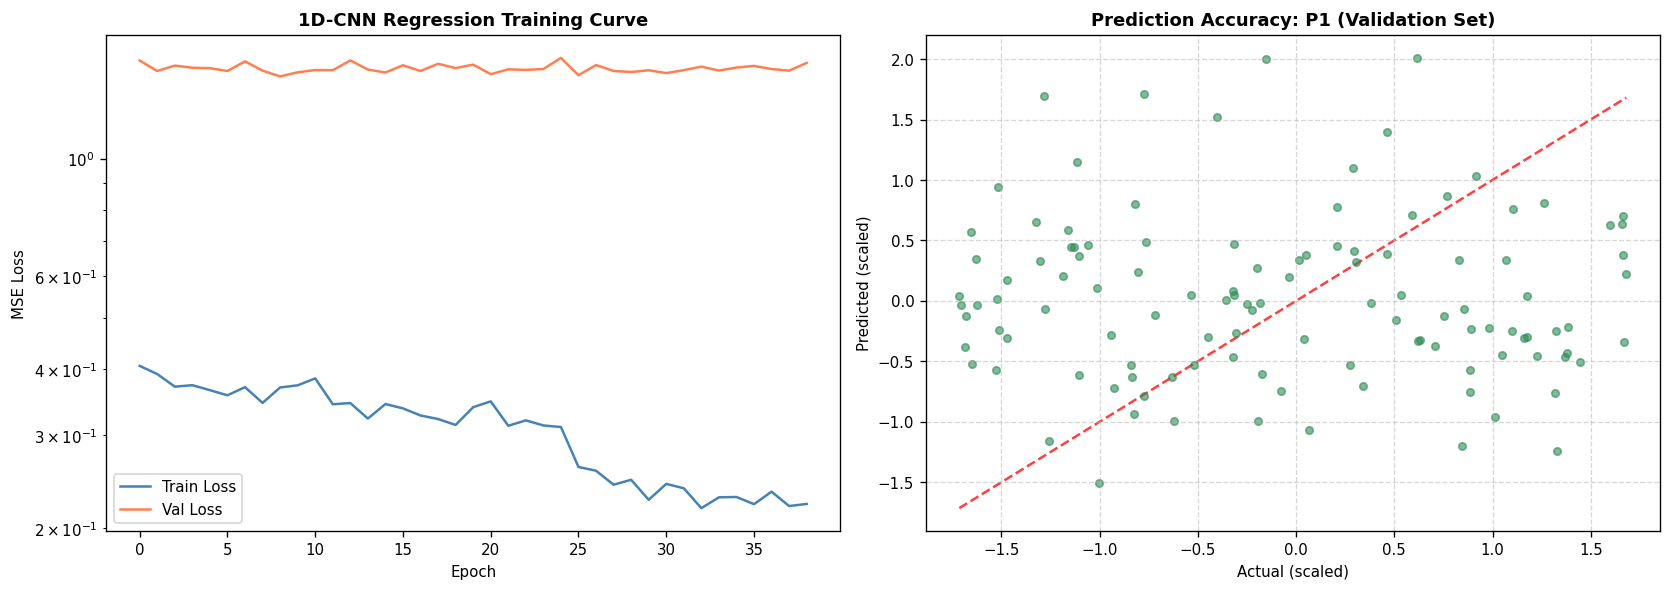


[검증 세트 평균 오차(MAE)]
  P1: 1.0330
  P2: 1.0042
  P3: 0.9401
  P4: 1.0511
  P5: 1.0311
  P6: 0.9458


In [109]:
# ====================================================================
# [5. 1D-CNN Regression 학습 결과 및 예측 성능 시각화]
# ====================================================================

# 설계 변수 레이블 정의 (누락된 경우 추가)
p_labels = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (A) 학습 곡선 (Loss Curve) ---
ax = axes[0]
ax.plot(cnn_train_losses, label='Train Loss', color='steelblue')
ax.plot(cnn_val_losses, label='Val Loss', color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('1D-CNN Regression Training Curve', fontweight='bold')
ax.legend()
ax.set_yscale('log') # 손실값이 작으므로 로그 스케일로 확인

# --- (B) 예측 성능 검증 (Actual vs Predicted) ---
# 검증 데이터셋에 대해 예측 수행
ax = axes[1]
model_direct.eval()
with torch.no_grad():
    val_x = X_tensor[val_idx].to(device)
    val_p_true = P_tensor[val_idx].cpu().numpy()
    val_p_pred = model_direct(val_x).cpu().numpy()

# 6개의 변수 중 대표로 P1(첫 번째 설계 변수)의 예측 성능 확인
# (전체 변수를 다 보려면 이전에 작성했던 P1~P6 Scatter Plot 코드를 활용하면 좋습니다)
p_idx = 0 
ax.scatter(val_p_true[:, p_idx], val_p_pred[:, p_idx], alpha=0.6, color='seagreen', s=20)

# y=x 대각선 (완벽한 예측일 때의 기준선)
lims = [min(val_p_true[:, p_idx]), max(val_p_true[:, p_idx])]
ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0)

ax.set_xlabel('Actual (scaled)')
ax.set_ylabel('Predicted (scaled)')
ax.set_title(f'Prediction Accuracy: {p_labels[p_idx]} (Validation Set)', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 추가: 전체 P1~P6에 대한 평균 MAE 출력
mae_per_param = np.mean(np.abs(val_p_pred - val_p_true), axis=0)
print("\n[검증 세트 평균 오차(MAE)]")
for i, p_name in enumerate(p_labels):
    print(f"  {p_name}: {mae_per_param[i]:.4f}")


[8] 1D-CNN 성능 검증 (Validation Set)
   변수 |        MAE |       상대오차 |                 실제범위
-------------------------------------------------------
   P1 |     0.0884 |     9.40%  | [0.8007, 1.0914]
   P2 |     0.0115 |    16.80%  | [0.0500, 0.0894]
   P3 |     0.0318 |     4.87%  | [0.6007, 0.7188]
   P4 |     0.0514 |    27.82%  | [0.1003, 0.2993]
   P5 |     0.1783 |    12.02%  | [1.2004, 1.7985]
   P6 |     0.0110 |    18.36%  | [0.0402, 0.0796]


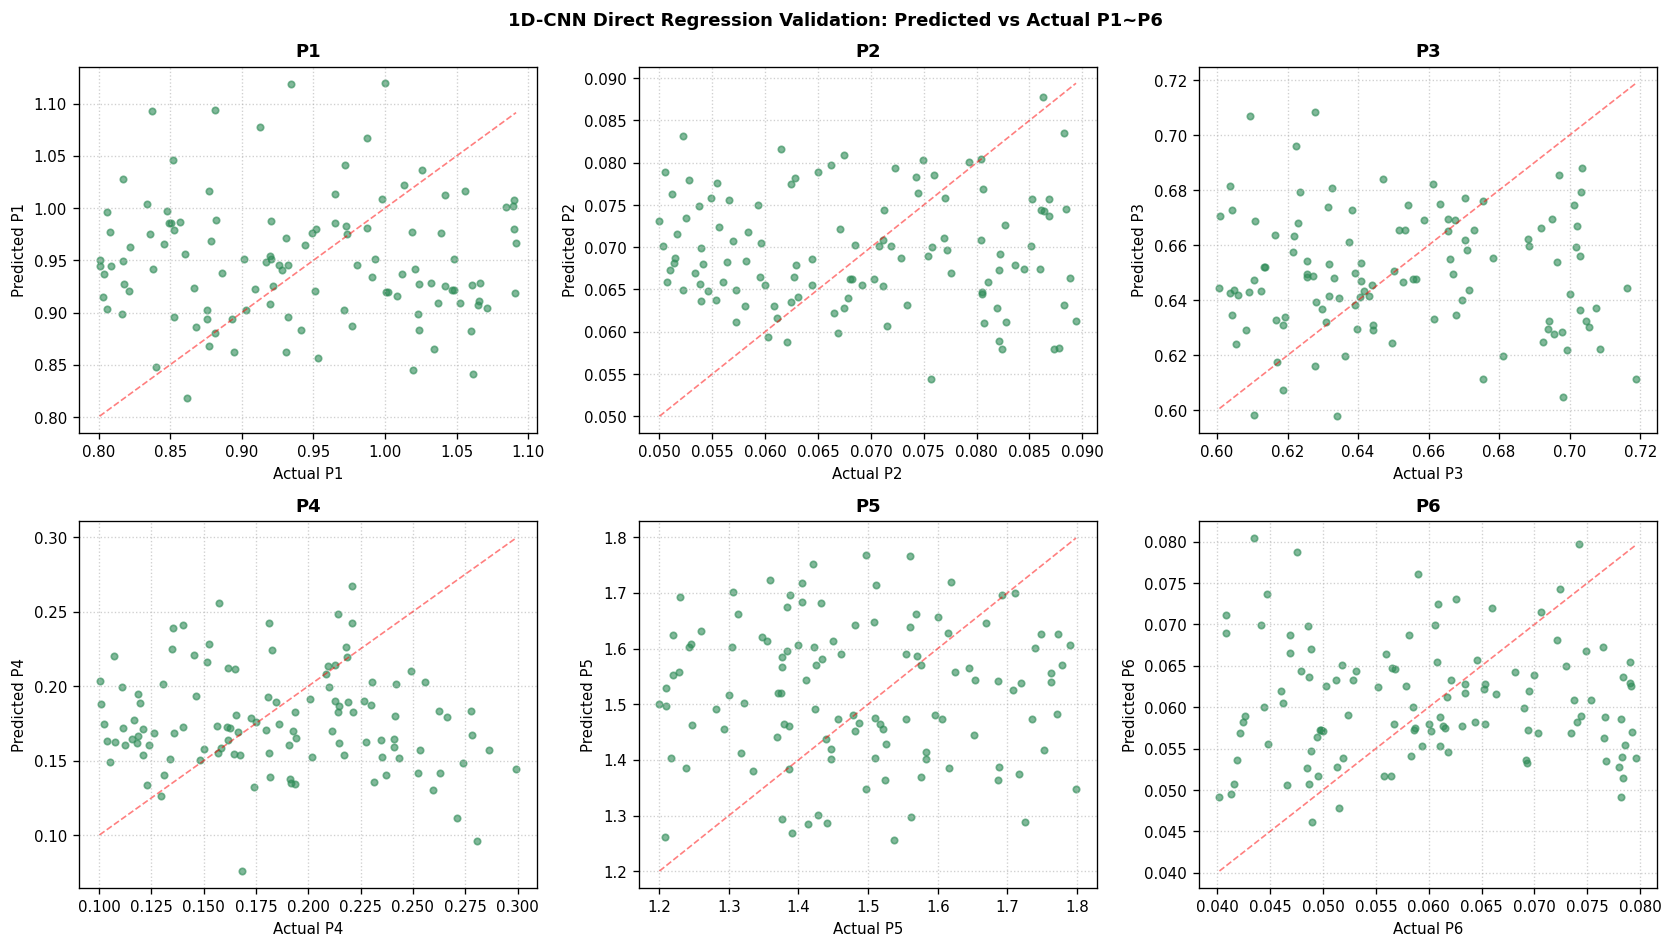

In [110]:
# ====================================================================
# [8. 1D-CNN Regression 성능 검증]
# ====================================================================
# Validation 데이터에서 시계열 -> P1~P6 예측 정확도 확인

print('\n[8] 1D-CNN 성능 검증 (Validation Set)')

model_direct.eval()
with torch.no_grad():
    # 입력: 검증 세트의 시계열 텐서
    val_x = X_tensor[val_idx].to(device)
    # 모델 추론 (scaled P값 출력)
    p_pred_val = model_direct(val_x).cpu().numpy()

# 역정규화하여 실제 P 스케일(mm, MPa 등)로 복원
p_pred_actual = param_scaler.inverse_transform(p_pred_val)
p_true_actual = param_scaler.inverse_transform(P_tensor[val_idx].numpy())

# 변수별 MAE 및 상대 오차율 출력
p_labels = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
print(f'{"변수":>5s} | {"MAE":>10s} | {"상대오차":>10s} | {"실제범위":>20s}')
print('-' * 55)
for i, p in enumerate(p_labels):
    mae = np.mean(np.abs(p_pred_actual[:, i] - p_true_actual[:, i]))
    mean_val = np.mean(np.abs(p_true_actual[:, i]))
    rel_err = mae / mean_val * 100  # 상대 오차(%)
    p_min, p_max = p_true_actual[:, i].min(), p_true_actual[:, i].max()
    print(f'{p:>5s} | {mae:10.4f} | {rel_err:8.2f}%  | [{p_min:.4f}, {p_max:.4f}]')

# Pred vs Actual 시각화 (6개 변수 전체)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('1D-CNN Direct Regression Validation: Predicted vs Actual P1~P6', fontweight='bold')

for i, (ax, p) in enumerate(zip(axes.flat, p_labels)):
    ax.scatter(p_true_actual[:, i], p_pred_actual[:, i], s=15, alpha=0.6, c='seagreen') # 색상 변경
    # y=x 대각선 기준선
    lims = [p_true_actual[:, i].min(), p_true_actual[:, i].max()]
    ax.plot(lims, lims, 'r--', linewidth=1, alpha=0.5) 
    ax.set_xlabel(f'Actual {p}')
    ax.set_ylabel(f'Predicted {p}')
    ax.set_title(p, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 1D-CNN 단일 사용 결과 -> 1D-CNN+AE보다 성능이 낮음

이유: 시계열에서 특징을 추출하는 법과 P를 예측하는 법을 동시에 배우려다 보니 길을 잃은 것으로 보임. -> 데이터의 수가 충분치 않고, 지금 진행하는 역설계는 관계가 매우 복잡하고 비선형적이어서 단독 학습이 어려움.

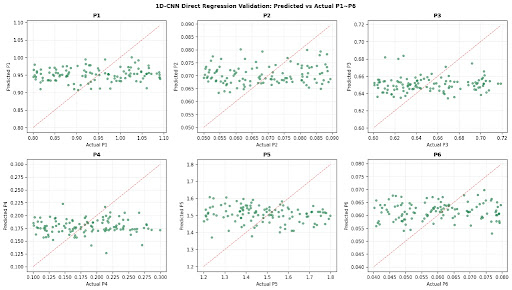